# 映画評価分布・選択バイアス・ランキング不確実性

run_id: `v020-exp-44`。公開MovieLens対応データをKaggle SDKから取得する。作品・複数ジャンル・利用者の分布を比較し、利用者単位クラスターブートストラップで反復測定を扱う。未評価を低評価と置き換えず、観察された評価の記述・関連だけを報告する。APIトークン・認証設定・例外本文は出力しない。実行はJupyter MCPのセルだけで行う。


In [ ]:
from pathlib import Path
import sys, os, json, hashlib, io, contextlib, zipfile, re, warnings
from datetime import datetime, timezone
from dataclasses import asdict
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
ROOT = Path('/home/nahisaho/GitHub/jupytermind')
sys.path.insert(0, str(ROOT / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(ROOT / 'benchmark/projects')
from ai_data_scientist import project_manager as pm, lifecycle, language_router
from ai_data_scientist import data_definition as dd, analysis_assumptions as aa
from ai_data_scientist import data_quality as dq, sensitivity, eda, visualization, notebook_audit
handle = pm.resolve_project('kaggle-v020-kaggle-exp-44-movie-ratings')
pm.ensure_notebook(handle)
data_dir = pm.ensure_data_dir(handle)
RUN_ID = 'v020-exp-44'
lifecycle.register_run(RUN_ID, handle.notebook_path)
phase_log = []
def phase_start(name):
    if lifecycle.is_cancel_requested(RUN_ID):
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('実行中止要求を検出')
    lifecycle.mark_execution_start(RUN_ID)
    phase_log.append({'phase': name, 'event': 'execution_start', 'time': datetime.now(timezone.utc).isoformat()})
def phase_end(name):
    lifecycle.mark_execution_end(RUN_ID)
    phase_log.append({'phase': name, 'event': 'execution_end', 'time': datetime.now(timezone.utc).isoformat()})
def write_notebook(mutation):
    lifecycle.mark_write_start(RUN_ID)
    phase_log.append({'phase': 'notebook', 'event': 'write_start'})
    try:
        pm.enqueue_write(handle, mutation)
    finally:
        lifecycle.mark_write_end(RUN_ID)
        phase_log.append({'phase': 'notebook', 'event': 'write_end'})
def add_cells(cells):
    write_notebook(lambda nb: nb.cells.extend(cells))
language = language_router.detect_language('映画評価分布を日本語で分析してください')
print('run_id:', RUN_ID, 'language:', language)
print('保存先:', handle.notebook_path)


In [2]:
phase_start('kaggle_search')
api_ok = False
acquisition_errors = []
search_records = []
file_records = []
selected_slug = None
try:
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        from kaggle.api.kaggle_api_extended import KaggleApi
        api = KaggleApi()
        api.authenticate()
        datasets = api.dataset_list(search='movielens', page=1)
    for d in datasets:
        search_records.append({'ref': str(d.ref), 'title': str(d.title), 'size': str(getattr(d, 'total_bytes', getattr(d, 'totalBytes', 'unknown')))})
    display(pd.DataFrame(search_records))
    candidates = sorted(search_records, key=lambda x: (0 if 'small' in x['title'].lower() or 'small' in x['ref'].lower() else 1, 0 if 'latest' in x['ref'].lower() else 1))
    for candidate in candidates[:12]:
        slug = candidate['ref']
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            listing = api.dataset_list_files(slug)
        files = [{'name': f.name, 'size': int(getattr(f, 'total_bytes', getattr(f, 'totalBytes', 0)) or 0)} for f in listing.files]
        file_records.append({'slug': slug, 'files': files})
        names = [f['name'] for f in files]
        ratings_names = [n for n in names if n.lower().endswith('ratings.csv')]
        movies_names = [n for n in names if n.lower().endswith('movies.csv')]
        if ratings_names and movies_names:
            selected_slug = slug
            selected_files = [ratings_names[0], movies_names[0]]
            readme_files = [n for n in names if 'readme' in n.lower()]
            selected_files += readme_files[:1]
            api_ok = True
            break
except (Exception, SystemExit) as exc:
    acquisition_errors.append({'stage': 'authenticate/search/list_files', 'error_type': type(exc).__name__, 'detail': '秘密情報防止のため例外本文は非表示'})
finally:
    phase_end('kaggle_search')
print(json.dumps({'api_ok': api_ok, 'slug': selected_slug, 'files': selected_files if api_ok else [], 'errors': acquisition_errors}, ensure_ascii=False, indent=2))
print('確認したファイル一覧:', json.dumps(file_records, ensure_ascii=False))


{
  "api_ok": true,
  "slug": "grouplens/movielens-latest-small",
  "files": [
    "ratings.csv",
    "movies.csv",
    "README.md"
  ],
  "errors": []
}
確認したファイル一覧: [{"slug": "grouplens/movielens-latest-small", "files": [{"name": "README.md", "size": 8342}, {"name": "links.csv", "size": 197979}, {"name": "movies.csv", "size": 494431}, {"name": "ratings.csv", "size": 2483723}, {"name": "tags.csv", "size": 118660}]}]


,ref,title,size
0,grouplens/movielens-20m-dataset,MovieLens 20M Dataset,204953792
1,sherinclaudia/movielens,Movielens,6109178
2,ayushimishra2809/movielens-dataset,Movielens dataset,896112
3,snehal1409/movielens,MovieLens,932188
4,rounakbanik/the-movies-dataset,The Movies Dataset,238862293
5,sriharshabsprasad/movielens-dataset-100k-ratings,MovieLens Dataset - 100K Ratings,994099
6,jneupane12/movielens,MovieLens,12528088
7,amirmotefaker/movielens-10m-dataset-latest-ver...,MovieLens 10M Dataset (Latest Version),67393808
8,akkefa/movielens-9000-movies-dataset,MovieLens 9000 Movies Dataset,994099
9,rajmehra03/movielens100k,MovieLens-100K,1776991


In [3]:
phase_start('kaggle_download')
import nbformat
from ai_data_scientist import ingestion, insight_engine
provenance = []
paths = {}
try:
    if not api_ok:
        raise RuntimeError('Kaggle取得先の特定に失敗')
    for name in selected_files:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            api.dataset_download_file(selected_slug, name, path=str(data_dir), force=False, quiet=True)
        target = data_dir / Path(name).name
        zipped = data_dir / (Path(name).name + '.zip')
        if not target.exists() and zipped.exists():
            with zipfile.ZipFile(zipped) as archive:
                members = [m for m in archive.namelist() if Path(m).name == Path(name).name]
                if len(members) != 1:
                    raise ValueError('ZIP内に目的ファイルが一意に存在しない')
                target.write_bytes(archive.read(members[0]))
        if not target.exists():
            raise FileNotFoundError('取得ファイルが存在しない')
        paths[Path(name).name] = target
        provenance.append({'owner_dataset_slug': selected_slug, 'kaggle_filename': name, 'local_filename': target.name, 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': hashlib.sha256(target.read_bytes()).hexdigest(), 'bytes': target.stat().st_size, 'method': 'Kaggle SDK dataset_download_file; force=False（キャッシュ再利用可能）'})
except (Exception, SystemExit) as exc:
    acquisition_errors.append({'stage': 'download', 'error_type': type(exc).__name__, 'detail': '例外本文非表示'})
    paper_path = Path('/home/nahisaho/kaggle/experiments/white-paper.md')
    paper = paper_path.read_text(encoding='utf-8') if paper_path.exists() else ''
    corresponding = [line for line in paper.splitlines() if 'movielens' in line.lower() and '.csv' in line.lower() and 'http' in line]
    print('取得失敗:', acquisition_errors)
    print('white-paper対応CSV記載:', corresponding)
    lifecycle.mark_failed(RUN_ID)
    raise RuntimeError('取得失敗。同一データの公開CSVを確認できなければ代替データは選択しない。') from None
finally:
    phase_end('kaggle_download')
provenance_path = data_dir / 'provenance.json'
if provenance_path.exists():
    original = json.loads(provenance_path.read_text(encoding='utf-8'))
    original_hashes = {p['kaggle_filename']: p['sha256'] for p in original}
    assert {p['kaggle_filename']: p['sha256'] for p in provenance} == original_hashes, '再実行時に取得ファイルが変更された'
    for p in provenance:
        p['initial_retrieved_at_utc'] = next(o.get('initial_retrieved_at_utc', o['retrieved_at_utc']) for o in original if o['kaggle_filename'] == p['kaggle_filename'])
provenance_path.write_text(json.dumps(provenance, ensure_ascii=False, indent=2), encoding='utf-8')
display(pd.DataFrame(provenance))
ratings_load = ingestion.ingest(ingestion.SourceSpec('csv', str(paths['ratings.csv'])), row_limit=200_000)
movies_load = ingestion.ingest(ingestion.SourceSpec('csv', str(paths['movies.csv'])), row_limit=50_000)
assert not ratings_load.truncated and not movies_load.truncated, '全件分析の前提違反'
ratings = ratings_load.dataframe
movies = movies_load.dataframe
readme = paths['README.md'].read_text(encoding='utf-8')
print('README定義抜粋:')
for phrase in ['100,836', '610', '9,742', 'half-star', 'random', '20 movies', 'September', 'March', '1970', 'genres', 'Development']:
    for line in readme.splitlines():
        if phrase.lower() in line.lower():
            print(line[:1400])
print('実行セル内のAPI取得成功。white-paperフォールバックは不要。')


README定義抜粋:
This dataset (ml-latest-small) describes 5-star rating and free-text tagging activity from [MovieLens](http://movielens.org), a movie recommendation service. It contains 100836 ratings and 3683 tag applications across 9742 movies. These data were created by 610 users between March 29, 1996 and September 24, 2018. This dataset was generated on September 26, 2018.
Ratings are made on a 5-star scale, with half-star increments (0.5 stars - 5.0 stars).
Users were selected at random for inclusion. All selected users had rated at least 20 movies. No demographic information is included. Each user is represented by an id, and no other information is provided.
MovieLens users were selected at random for inclusion. Their ids have been anonymized. User ids are consistent between `ratings.csv` and `tags.csv` (i.e., the same id refers to the same user across the two files).
Users were selected at random for inclusion. All selected users had rated at least 20 movies. No demographic inform

,owner_dataset_slug,kaggle_filename,local_filename,retrieved_at_utc,sha256,bytes,method,initial_retrieved_at_utc
0,grouplens/movielens-latest-small,ratings.csv,ratings.csv,2026-10-01T23:06:47.647270+00:00,aa289ca83157595d0df6aea1be6a4ded676ddc4385472e...,2483723,Kaggle SDK dataset_download_file; force=False（...,2026-10-01T22:56:14.949895+00:00
1,grouplens/movielens-latest-small,movies.csv,movies.csv,2026-10-01T23:06:48.251719+00:00,5a5f32dd9bb3797b8e728a1b98958789d2b13f294a69fd...,494431,Kaggle SDK dataset_download_file; force=False（...,2026-10-01T22:56:16.469385+00:00
2,grouplens/movielens-latest-small,README.md,README.md,2026-10-01T23:06:48.860673+00:00,63d22ac138e80fae37021797ed8e1b9424b5239dc576a1...,8342,Kaggle SDK dataset_download_file; force=False（...,2026-10-01T22:56:17.121147+00:00


## データ定義・分析前提・意味的な品質検査

評価の単位・時刻・標本選択は取得したREADMEで確認する。評価尺度は順序尺度でもあり、平均値は等間隔という作業上の仮定に依存するため、低評価・高評価比率も併記する。ジャンルは複数所属であり、通常の独立群検定は使わない。評価が少ない作品を削除して全体分布を美化せず、ランキングにだけ最低件数を設定する。

In [4]:
phase_start('definitions_quality')
FV = dd.FieldValue
manifest = dd.build_manifest(
    source={'kaggle_slug': FV(selected_slug, 'verified', 'Kaggle API'), 'files': FV(provenance, 'verified', 'ローカルSHA-256'), 'definition': FV('同一取得README.md', 'verified', str(paths['README.md'])), 'license': FV('MovieLens READMEのUsage License。無制限の再配布許諾とは解釈しない', 'verified', 'README.md')},
    dataset_scope={'population': FV('MovieLensで少なくとも20作品を評価した選択利用者610人。一般映画視聴者ではない', 'verified', 'README.md'), 'period': FV('1996-03-29〜2018-09-24、2018-09-26生成', 'verified', 'README.md'), 'sampling': FV('対象MovieLens利用者からランダム選択とREADMEに記載。未評価の選択機構は不明', 'verified', 'README.md'), 'general_population_selection_probability': FV(None, 'unknown', '視聴・非評価ログなし')},
    variables={'rating': {'unit': FV('星、0.5〜5.0、0.5刻み', 'verified', 'README.md'), 'meaning': FV('利用者の作品に対する自己申告評価', 'verified', 'README.md')}, 'userId': {'meaning': FV('匿名利用者識別子、反復測定クラスタ', 'verified', 'README.md')}, 'movieId': {'meaning': FV('作品識別子、movies.csvへの結合キー', 'verified', 'README.md')}, 'genres': {'meaning': FV('パイプ区切り複数ジャンル、(no genres listed)は未分類', 'verified', 'README.md')}, 'timestamp': {'unit': FV('1970-01-01 UTCからの秒', 'verified', 'README.md')}, 'rating_count': {'meaning': FV('この標本での評価件数。視聴回数・興収・一般人気ではない', 'verified', 'ratings.csv集計')}})
unresolved_fields = manifest.unresolved_fields()
definition_record = asdict(manifest)
print(json.dumps(definition_record, ensure_ascii=False, indent=2))
print('未解決定義:', [(p, asdict(f)) for p, f in unresolved_fields])
allowed_genres = {'Action','Adventure','Animation',"Children",'Comedy','Crime','Documentary','Drama','Fantasy','Film-Noir','Horror','IMAX','Musical','Mystery','Romance','Sci-Fi','Thriller','War','Western','(no genres listed)'}
rating_anomalies = dq.detect_anomalies(ratings, {'userId': {'min':1,'not_null':True}, 'movieId': {'min':1,'not_null':True}, 'rating': {'allowed':np.arange(.5,5.1,.5), 'not_null':True}, 'timestamp': {'min':0,'not_null':True}})
movie_anomalies = dq.detect_anomalies(movies, {'movieId': {'unique':True,'not_null':True}, 'title': {'not_null':True}, 'genres': {'not_null':True}})
genre_tokens = movies.assign(genre=movies.genres.str.split('|')).explode('genre')
genre_anomalies = dq.detect_anomalies(genre_tokens, {'genre':{'allowed':allowed_genres,'not_null':True}})
quality = {'ratings_rows':len(ratings),'movies_rows':len(movies),'users':ratings.userId.nunique(), 'rated_movies':ratings.movieId.nunique(), 'exact_duplicate_rows':int(ratings.duplicated().sum()), 'duplicate_user_movie_pairs':int(ratings.duplicated(['userId','movieId']).sum()), 'orphan_movie_ids':int((~ratings.movieId.isin(movies.movieId)).sum()), 'semantic_anomalies':[asdict(a) for a in rating_anomalies+movie_anomalies+genre_anomalies], 'missing_values':ratings.isna().sum().to_dict()}
assert not rating_anomalies and not movie_anomalies and not genre_anomalies, '意味的制約違反'
assert quality['duplicate_user_movie_pairs'] == quality['orphan_movie_ids'] == 0, '結合・反復識別違反'
assert (ratings[['userId','movieId','timestamp']] % 1 == 0).all().all(), '整数識別子/時刻違反'
ratings['rated_at'] = pd.to_datetime(ratings.timestamp, unit='s', utc=True)
quality['time_min'] = str(ratings.rated_at.min())
quality['time_max'] = str(ratings.rated_at.max())
quality['future_timestamps'] = int((ratings.rated_at > pd.Timestamp.now(tz='UTC')).sum())
assert quality['future_timestamps'] == 0
print(json.dumps(quality, ensure_ascii=False, indent=2))
print('クリーニング: 違反なし。削除0行、補完0件。整数ID・外部キー・重複対は明示追加検査。')
eda_result = eda.explore(ratings)
print('EDA型:', eda_result.dtypes)
assumptions = aa.AnalysisAssumptionManifest(
    analysis_scope={'estimand':'観察された評価の作品/ジャンル/利用者別分布、標本内ランキング', 'not_estimand':'映画の因果効果・全視聴者の好み・視聴人気'},
    assumptions=(aa.Assumption('interval-stars','星の差を平均計算では等間隔と扱う。閾値分布を併記', 'assumed', conclusion_critical=True, impact_if_false='平均順位の解釈に影響'), aa.Assumption('user-clusters','利用者内評価は独立ではなく、利用者単位再標本化', 'tested'), aa.Assumption('independent-users','利用者クラスタ相互は独立・同じ対象母集団から交換可能', 'assumed', conclusion_critical=True, impact_if_false='区間推定が狭すぎる可能性'), aa.Assumption('representative-viewers','MovieLens対象者は一般映画視聴者を代表する', 'rejected', conclusion_critical=True, impact_if_false='一般母集団へ外挿不可'), aa.Assumption('missing-at-random','未評価作品の評価は無作為に欠測する', 'rejected', conclusion_critical=True, impact_if_false='露出と自己選択は観測できず補正不能'), aa.Assumption('genre-overlap','全所属への重複計上を主解析とし、分数計上を感度分析', 'tested'), aa.Assumption('shrinkage','全体平均に20件相当の縮約を行う。実証ベイズ適合や真の事後確率ではない', 'tested')),
    causal_scope='associational', sampling={'n':len(ratings),'seed':44,'subset':'全取得行、ランキングだけ20件以上'})
assumption_findings = aa.check_manifest(assumptions)
print('分析前提manifest:', json.dumps(asdict(assumptions), ensure_ascii=False, indent=2))
print('前提警告（全件）:', json.dumps([asdict(x) for x in assumption_findings], ensure_ascii=False, indent=2))
phase_end('definitions_quality')


{
  "source": {
    "kaggle_slug": {
      "value": "grouplens/movielens-latest-small",
      "status": "verified",
      "source": "Kaggle API"
    },
    "files": {
      "value": [
        {
          "owner_dataset_slug": "grouplens/movielens-latest-small",
          "kaggle_filename": "ratings.csv",
          "local_filename": "ratings.csv",
          "retrieved_at_utc": "2026-10-01T23:06:47.647270+00:00",
          "sha256": "aa289ca83157595d0df6aea1be6a4ded676ddc4385472e8313a8ed9805352646",
          "bytes": 2483723,
          "method": "Kaggle SDK dataset_download_file; force=False（キャッシュ再利用可能）",
          "initial_retrieved_at_utc": "2026-10-01T22:56:14.949895+00:00"
        },
        {
          "owner_dataset_slug": "grouplens/movielens-latest-small",
          "kaggle_filename": "movies.csv",
          "local_filename": "movies.csv",
          "retrieved_at_utc": "2026-10-01T23:06:48.251719+00:00",
          "sha256": "5a5f32dd9bb3797b8e728a1b98958789d2b13f294a69fdfbc5727f

## 初回分析：作品・ジャンル・利用者の分布

全件で平均・中央値・標準偏差・低評価（2以下）・高評価（4以上）を示す。作品の件数0はカタログに存在するがこの標本で未評価。ジャンルの件数合計は複数所属により評価総数を超える。利用者内中心化は個人の平均評価との差であり、因果的なジャンル効果の推定ではない。

In [5]:
phase_start('initial_distribution')
from scipy import stats as ss
from scipy.sparse import csr_matrix
joined = ratings.merge(movies, on='movieId', how='left', validate='many_to_one')
user_stats = ratings.groupby('userId').rating.agg(n='size', mean='mean', median='median', sd='std')
movie_stats = ratings.groupby('movieId').rating.agg(n='size', mean='mean', median='median', sd='std', low=lambda s:(s<=2).mean(), high=lambda s:(s>=4).mean())
movie_catalog = movies.set_index('movieId').join(movie_stats)
movie_catalog['n'] = movie_catalog.n.fillna(0).astype(int)
joined['user_mean'] = joined.userId.map(user_stats['mean'])
joined['centered'] = joined.rating - joined.user_mean
joined['genre_list'] = joined.genres.str.split('|')
joined['genre_k'] = joined.genre_list.str.len()
long = joined.explode('genre_list').rename(columns={'genre_list':'genre'})
long['fraction_weight'] = 1 / long.genre_k
named_long = long[long.genre != '(no genres listed)'].copy()
genre_stats = long.groupby('genre').agg(n=('rating','size'), users=('userId','nunique'), movies=('movieId','nunique'), mean=('rating','mean'), median=('rating','median'), sd=('rating','std'), low=('rating', lambda s:(s<=2).mean()), high=('rating', lambda s:(s>=4).mean()), centered=('centered','mean')).sort_values('mean', ascending=False)
genre_user = long.groupby(['userId','genre']).rating.mean()
genre_stats['user_equal_mean'] = genre_user.groupby('genre').mean()
rating_distribution = ratings.rating.value_counts().sort_index().rename_axis('rating').reset_index(name='n')
rating_distribution['percent'] = 100*rating_distribution.n/len(ratings)
counts = np.sort(movie_catalog.n.to_numpy())
gini = (2*np.sum(np.arange(1,len(counts)+1)*counts)/(len(counts)*counts.sum()))-(len(counts)+1)/len(counts)
top_decile_n = int(np.ceil(.1*len(movie_catalog)))
popularity = {'top_10pct_movies_rating_share':float(movie_catalog.nlargest(top_decile_n,'n').n.sum()/len(ratings)), 'gini_rating_counts':float(gini), 'unobserved_user_movie_fraction':float(1-len(ratings)/(len(user_stats)*len(movies))), 'spearman_n_mean':float(ss.spearmanr(movie_stats.n,movie_stats['mean']).statistic)}
initial_summary = {'ratings':len(ratings),'users':len(user_stats),'catalog_movies':len(movies),'rated_movies':len(movie_stats),'zero_rating_movies':int((movie_catalog.n==0).sum()), 'movies_n_le_5':int(((movie_catalog.n>=1)&(movie_catalog.n<=5)).sum()), 'pct_rated_movies_n_le_5':float(100*(movie_stats.n<=5).mean()), 'movies_n1':int((movie_stats.n==1).sum()), 'five_star_mean_movies':int((movie_stats['mean']==5).sum()), 'rating_weighted_mean':float(ratings.rating.mean()), 'movie_equal_mean':float(movie_stats['mean'].mean()), 'user_equal_mean':float(user_stats['mean'].mean()), 'user_n_min':int(user_stats.n.min()), 'user_n_max':int(user_stats.n.max()), 'user_mean_min':float(user_stats['mean'].min()), 'user_mean_max':float(user_stats['mean'].max()), **popularity}
N,U = len(ratings),len(user_stats)
MSW = float(np.sum((ratings.rating - ratings.userId.map(user_stats['mean']))**2)/(N-U))
MSB = float(np.sum(user_stats.n*(user_stats['mean']-ratings.rating.mean())**2)/(U-1))
n0 = float((N-np.sum(user_stats.n**2)/N)/(U-1))
user_variance = max(0,(MSB-MSW)/n0)
icc = user_variance/(user_variance+MSW)
initial_summary['unadjusted_user_icc'] = float(icc)
user_stats['activity_group'] = pd.qcut(user_stats.n.rank(method='first'),4,labels=['Q1低活動','Q2','Q3','Q4高活動'])
activity_table = user_stats.groupby('activity_group', observed=True).agg(users=('n','size'), ratings=('n','sum'), mean_user_rating=('mean','mean'), n_median=('n','median'))
display(Markdown('初回集計値: '+json.dumps(initial_summary,ensure_ascii=False)))
display(rating_distribution)
display(movie_catalog.n.describe(percentiles=[.25,.5,.75,.9,.99]).to_frame('作品別評価件数'))
display(user_stats[['n','mean','sd']].describe().T)
display(activity_table)
display(genre_stats.round(4))
print('生の平均上位（単発作品の同率多数を含む）:')
display(movie_catalog.sort_values(['mean','n'],ascending=[False,False]).head(15)[['title','n','mean','sd']])
phase_end('initial_distribution')


生の平均上位（単発作品の同率多数を含む）:


初回集計値: {"ratings": 100836, "users": 610, "catalog_movies": 9742, "rated_movies": 9724, "zero_rating_movies": 18, "movies_n_le_5": 6456, "pct_rated_movies_n_le_5": 66.39243109831345, "movies_n1": 3446, "five_star_mean_movies": 296, "rating_weighted_mean": 3.501556983616962, "movie_equal_mean": 3.2624482748109633, "user_equal_mean": 3.6572223377474, "user_n_min": 20, "user_n_max": 2698, "user_mean_min": 1.275, "user_mean_max": 5.0, "top_10pct_movies_rating_share": 0.6010254274267127, "gini_rating_counts": 0.7168044619369669, "unobserved_user_movie_fraction": 0.9830317267467884, "spearman_n_mean": 0.03958153228619635, "unadjusted_user_icc": 0.19216329891739692}

,rating,n,percent
0,0.5,1370,1.358642
1,1.0,2811,2.787695
2,1.5,1791,1.776151
3,2.0,7551,7.488397
4,2.5,5550,5.503987
5,3.0,20047,19.880797
6,3.5,13136,13.027093
7,4.0,26818,26.595660
8,4.5,8551,8.480106
9,5.0,13211,13.101472


,作品別評価件数
count,9742.000000
mean,10.350647
std,22.384729
min,0.000000
25%,1.000000
50%,3.000000
75%,9.000000
90%,27.000000
99%,114.180000
max,329.000000


,count,mean,std,min,25%,50%,75%,max
n,610.0,165.304918,269.480584,20.000,35.000000,70.500000,168.000000,2698.000000
mean,610.0,3.657222,0.480635,1.275,3.360000,3.694385,3.997500,5.000000
sd,610.0,0.927116,0.266108,0.000,0.736026,0.902378,1.079056,2.090642


,users,ratings,mean_user_rating,n_median
activity_group,,,,
Q1低活動,153,4052,3.668093,26.0
Q2,152,7655,3.745481,50.0
Q3,152,17176,3.678463,111.0
Q4高活動,153,71953,3.537569,340.0


,n,users,movies,mean,median,sd,low,high,centered,user_equal_mean
genre,,,,,,,,,,
Film-Noir,870,239,85,3.9201,4.0,0.8870,0.0586,0.6759,0.3513,3.8496
War,4859,551,381,3.8083,4.0,0.9785,0.0784,0.6164,0.2426,3.8706
Documentary,1219,223,438,3.7978,4.0,0.8205,0.0468,0.5980,0.2776,3.7800
Crime,16681,603,1196,3.6583,4.0,0.9947,0.0995,0.5442,0.1254,3.7579
Drama,41928,610,4349,3.6562,4.0,0.9791,0.0960,0.5468,0.1273,3.7568
Mystery,7674,580,573,3.6325,4.0,1.0063,0.1058,0.5374,0.0910,3.7594
Animation,6988,527,610,3.6299,4.0,0.9697,0.0913,0.5230,0.1210,3.6399
IMAX,4145,458,158,3.6183,4.0,0.9881,0.0948,0.5139,0.0436,3.8061
Western,1930,420,167,3.5839,4.0,1.0121,0.1145,0.5161,0.0862,3.6425


,title,n,mean,sd
movieId,,,,
53,Lamerica (1994),2,5.0,0.0
99,Heidi Fleiss: Hollywood Madam (1995),2,5.0,0.0
1151,Lesson Faust (1994),2,5.0,0.0
3473,Jonah Who Will Be 25 in the Year 2000 (Jonas q...,2,5.0,0.0
6442,Belle époque (1992),2,5.0,0.0
6818,Come and See (Idi i smotri) (1985),2,5.0,0.0
78836,Enter the Void (2009),2,5.0,0.0
148,"Awfully Big Adventure, An (1995)",1,5.0,NaN
467,Live Nude Girls (1995),1,5.0,NaN


## 利用者クラスターブートストラップとランキング

610人を復元抽出して、選ばれた各利用者の全評価を一緒に再標本化する（1,000回、seed=44）。作品の評価者はこの標本では1作品1利用者1件だが、複数作品・複数ジャンル比較には同一利用者が繰り返し現れる。作品ランキング対象は観測20件以上に固定。縮約スコア=(評価合計+20×標本全体平均)/(件数+20)は安定化指標であり、ベイズモデルではない。百分位95%区間は利用者抽出変動を表し、選択バイアス・作品母集団変動を含まない。順位区間・Top10頻度は固定候補集合内の再標本化頻度であり、真の順位の事後確率や同時信頼帯ではない。

In [6]:
phase_start('cluster_bootstrap')
B,SEED = 1000,44
rng = np.random.default_rng(SEED)
user_ids = np.sort(ratings.userId.unique())
uid_map = {u:i for i,u in enumerate(user_ids)}
W = rng.multinomial(len(user_ids),np.repeat(1/len(user_ids),len(user_ids)),size=B).astype(float)
user_totals = ratings.groupby('userId').rating.agg(['sum','size']).reindex(user_ids)
boot_global = (W@user_totals['sum'].to_numpy())/(W@user_totals['size'].to_numpy())
boot_user_equal = W@user_stats.reindex(user_ids)['mean'].to_numpy()/len(user_ids)
naive_se = float(ratings.rating.std(ddof=1)/np.sqrt(len(ratings)))
cluster_se = float(boot_global.std(ddof=1))
repeat_summary = {'global_mean':float(ratings.rating.mean()), 'naive_iid_SE':naive_se,'cluster_user_SE':cluster_se,'SE_ratio':cluster_se/naive_se,'cluster_CI95':np.quantile(boot_global,[.025,.975]).tolist(),'user_equal_CI95':np.quantile(boot_user_equal,[.025,.975]).tolist(),'icc_unadjusted':float(icc),'bootstrap_B':B,'seed':SEED}
eligible_ids = movie_stats.index[movie_stats.n>=20].to_numpy()
mid_map = {m:i for i,m in enumerate(eligible_ids)}
rk = ratings[ratings.movieId.isin(eligible_ids)]
rows = rk.userId.map(uid_map).to_numpy()
cols = rk.movieId.map(mid_map).to_numpy()
S = csr_matrix((rk.rating.to_numpy(),(rows,cols)),shape=(len(user_ids),len(eligible_ids)))
C = csr_matrix((np.ones(len(rk)),(rows,cols)),shape=S.shape)
bsum = np.asarray(S.T@W.T).T
bcount = np.asarray(C.T@W.T).T
assert (bcount>0).all(), 'ブートストラップで未評価候補が発生'
bmean = bsum/bcount
bscore = (bsum+20*boot_global[:,None])/(bcount+20)
rank_draws = np.argsort(np.argsort(-bscore,axis=1,kind='stable'),axis=1,kind='stable')+1
rank_table = movie_catalog.loc[eligible_ids,['title','n','mean']].copy()
rank_table['score_m20'] = (rank_table.n*rank_table['mean']+20*ratings.rating.mean())/(rank_table.n+20)
rank_table['mean_CI_low'],rank_table['mean_CI_high'] = np.quantile(bmean,[.025,.975],axis=0)
rank_table['score_CI_low'],rank_table['score_CI_high'] = np.quantile(bscore,[.025,.975],axis=0)
rank_table['rank_low'],rank_table['rank_high'] = np.quantile(rank_draws,[.025,.975],axis=0)
rank_table['top10_frequency'] = (rank_draws<=10).mean(axis=0)
rank_table['rank_m20'] = rank_table.score_m20.rank(method='min',ascending=False).astype(int)
rank_table = rank_table.sort_values('score_m20',ascending=False)
rank_summary = {'eligible_n20':len(eligible_ids),'top_title':rank_table.iloc[0].title,'top_score':float(rank_table.iloc[0].score_m20),'top_mean':float(rank_table.iloc[0]['mean']),'top_n':int(rank_table.iloc[0].n),'top_rank_interval':rank_table.iloc[0][['rank_low','rank_high']].tolist(),'top10_frequency_leader':float(rank_table.iloc[0].top10_frequency),'top1_frequency_leader':float((rank_draws[:,mid_map[rank_table.index[0]]]==1).mean())}
def dense_user_genre(long_df,value_col,weight_col=None):
    working = long_df.copy()
    working['_w'] = 1.0 if weight_col is None else working[weight_col]
    working['_s'] = working[value_col]*working['_w']
    gs = working.groupby(['userId','genre'])[['_s','_w']].sum()
    return (gs['_s'].unstack(fill_value=0).reindex(user_ids,fill_value=0),gs['_w'].unstack(fill_value=0).reindex(user_ids,fill_value=0))
GS,GC = dense_user_genre(long,'rating')
GCS,_ = dense_user_genre(long,'centered')
gboot = (W@GS.to_numpy())/(W@GC.to_numpy())
gcboot = (W@GCS.to_numpy())/(W@GC.to_numpy())
genre_stats['CI_low'],genre_stats['CI_high'] = pd.DataFrame(np.quantile(gboot,[.025,.975],axis=0).T,index=GS.columns).reindex(genre_stats.index).to_numpy().T
genre_stats['centered_CI_low'],genre_stats['centered_CI_high'] = pd.DataFrame(np.quantile(gcboot,[.025,.975],axis=0).T,index=GS.columns).reindex(genre_stats.index).to_numpy().T
display(Markdown('反復測定集計: '+json.dumps(repeat_summary,ensure_ascii=False)))
display(Markdown('ランキング集計: '+json.dumps(rank_summary,ensure_ascii=False)))
display(rank_table.head(15).round(4))
display(genre_stats[['n','users','mean','CI_low','CI_high','centered','centered_CI_low','centered_CI_high','user_equal_mean']].round(4))
rank_table.to_csv(data_dir/'ranking-user-bootstrap.csv',encoding='utf-8')
genre_stats.to_csv(data_dir/'genre-summary.csv',encoding='utf-8')
phase_end('cluster_bootstrap')


反復測定集計: {"global_mean": 3.501556983616962, "naive_iid_SE": 0.003283072243087202, "cluster_user_SE": 0.03504763098099717, "SE_ratio": 10.675254269775222, "cluster_CI95": [3.4319346850432457, 3.5712847610539753], "user_equal_CI95": [3.6206836731226257, 3.694477770074572], "icc_unadjusted": 0.19216329891739692, "bootstrap_B": 1000, "seed": 44}

ランキング集計: {"eligible_n20": 1297, "top_title": "Shawshank Redemption, The (1994)", "top_score": 4.373979642944627, "top_mean": 4.429022082018927, "top_n": 317, "top_rank_interval": [1.0, 1.0], "top10_frequency_leader": 1.0, "top1_frequency_leader": 0.99}

,title,n,mean,score_m20,mean_CI_low,mean_CI_high,score_CI_low,score_CI_high,rank_low,rank_high,top10_frequency,rank_m20
movieId,,,,,,,,,,,,
318,"Shawshank Redemption, The (1994)",317,4.4290,4.3740,4.3451,4.5031,4.2965,4.4447,1.0,1.000,1.000,1
858,"Godfather, The (1972)",192,4.2891,4.2148,4.1559,4.4133,4.0970,4.3242,2.0,23.025,0.827,2
2959,Fight Club (1999),218,4.2729,4.2081,4.1603,4.3790,4.1042,4.3057,2.0,25.000,0.808,3
260,Star Wars: Episode IV - A New Hope (1977),251,4.2311,4.1772,4.1182,4.3381,4.0731,4.2744,2.0,34.000,0.573,4
50,"Usual Suspects, The (1995)",204,4.2377,4.1720,4.1313,4.3357,4.0729,4.2613,2.0,32.000,0.540,5
527,Schindler's List (1993),220,4.2250,4.1647,4.0976,4.3486,4.0436,4.2781,2.0,39.050,0.487,6
1221,"Godfather: Part II, The (1974)",129,4.2597,4.1579,4.1211,4.3889,4.0363,4.2728,2.0,42.000,0.454,7
296,Pulp Fiction (1994),307,4.1971,4.1545,4.0954,4.2968,4.0583,4.2483,2.0,40.025,0.401,8
1196,Star Wars: Episode V - The Empire Strikes Back...,211,4.2156,4.1538,4.1116,4.3202,4.0559,4.2498,3.0,38.000,0.368,9


,n,users,mean,CI_low,CI_high,centered,centered_CI_low,centered_CI_high,user_equal_mean
genre,,,,,,,,,
Film-Noir,870,239,3.9201,3.8301,4.0125,0.3513,0.2697,0.4203,3.8496
War,4859,551,3.8083,3.7436,3.8772,0.2426,0.2086,0.2738,3.8706
Documentary,1219,223,3.7978,3.7013,3.8916,0.2776,0.2062,0.3397,3.7800
Crime,16681,603,3.6583,3.5884,3.7259,0.1254,0.1057,0.1432,3.7579
Drama,41928,610,3.6562,3.5902,3.7224,0.1273,0.1119,0.1418,3.7568
Mystery,7674,580,3.6325,3.5638,3.6976,0.0910,0.0623,0.1178,3.7594
Animation,6988,527,3.6299,3.5529,3.7133,0.1210,0.0811,0.1599,3.6399
IMAX,4145,458,3.6183,3.5258,3.7115,0.0436,-0.0083,0.0923,3.8061
Western,1930,420,3.5839,3.4992,3.6682,0.0862,0.0353,0.1381,3.6425


## 反復依頼履歴

### 反復1：原文
「初回ランキングは評価20件以上・20件相当の縮約に依存しています。最低評価件数を10・20・50・100件、縮約強度を0・10・20・50件に変え、首位とTop10の重なりを比較してください。1〜5件しか評価のない満点作品では経験的ブートストラップが不確実性を過小評価し得るため、有界尺度に基づく保守的区間も示し、高評価比率による別ランキングで星の等間隔仮定への依存を確認してください。」

選定理由：満点平均296作品と多数の単発作品があり、初回の固定閾値だけではランキングの安定性を説明しきれない。感度分析16仕様、評価尺度の別要約、低件数の支持範囲を確認する。結果・証拠は直後の実行セル、残る限界は後続の考察に記録する。

In [7]:
phase_start('iteration1_rank_sensitivity')
baseline_top10 = set(rank_table.head(10).index)
spec_details = []
def ranking_sensitivity(min_n, prior_n):
    t = movie_stats[movie_stats.n>=min_n].copy()
    t['score'] = (t.n*t['mean']+prior_n*ratings.rating.mean())/(t.n+prior_n)
    t = t.sort_values(['score','n'],ascending=[False,False])
    overlap = len(set(t.head(10).index)&baseline_top10)/10
    spec_details.append({'min_n':min_n,'prior_n':prior_n,'eligible':len(t),'leader':movies.set_index('movieId').loc[t.index[0],'title'],'leader_score':float(t.score.iloc[0]),'top10_overlap':overlap})
    return overlap
rank_sensitivity = sensitivity.run_sensitivity(sensitivity.SensitivityPlan({'min_n':[20,10,50,100],'prior_n':[20,0,10,50]},max_runs=16),ranking_sensitivity,stability_tolerance=.2)
sparse = movie_catalog[(movie_catalog.n>0)&(movie_catalog.n<=5)].copy()
M = len(movie_stats)
sparse['hoeffding_halfwidth_familywise'] = 4.5*np.sqrt(np.log(2*M/.05)/(2*sparse.n))
sparse['bounded_CI_low'] = np.maximum(.5,sparse['mean']-sparse.hoeffding_halfwidth_familywise)
sparse['bounded_CI_high'] = np.minimum(5,sparse['mean']+sparse.hoeffding_halfwidth_familywise)
sparse_example = sparse[sparse['mean']==5].sort_values('n').head(8)
# 評価者間独立という条件下の保守的同時区間。選択バイアスは補正しない。
z = ss.norm.ppf(.975)
ordinal_rank = movie_catalog[movie_catalog.n>=20].copy()
p = ordinal_rank.high
n = ordinal_rank.n
ordinal_rank['wilson_high_lower'] = (p+z*z/(2*n)-z*np.sqrt(p*(1-p)/n+z*z/(4*n*n)))/(1+z*z/n)
ordinal_rank = ordinal_rank.sort_values('wilson_high_lower',ascending=False)
iteration1 = {'sensitivity_stable':bool(rank_sensitivity.stable),'max_relative_deviation':rank_sensitivity.max_relative_deviation,'top10_overlap_min':float(min(d['top10_overlap'] for d in spec_details)),'distinct_leaders':sorted(set(d['leader'] for d in spec_details)),'singleton_five_star_movies':int(((movie_stats.n==1)&(movie_stats['mean']==5)).sum()),'high_rate_wilson_top_title':ordinal_rank.iloc[0].title,'ordinal_top10_overlap':len(set(ordinal_rank.head(10).index)&baseline_top10)/10,'sparse_full_scale_intervals':int(((sparse.bounded_CI_low==.5)&(sparse.bounded_CI_high==5)).sum())}
display(Markdown('反復1結果: '+json.dumps(iteration1,ensure_ascii=False)))
display(pd.DataFrame(spec_details).round(4))
display(sparse_example[['title','n','mean','bounded_CI_low','bounded_CI_high']])
display(ordinal_rank.head(10)[['title','n','high','wilson_high_lower']].round(4))
print('低件数の経験分布は新しい評価者の好みを学習できない。満点1件でも平均5が確定したとは言えない。Hoeffding区間は全9724作品でBonferroni、対象尺度0.5〜5、条件は評価者独立・同分布。標本内の選択効果や評点間隔仮定は残る。Wilson区間は高評価という別推定対象の点ごとの近似区間で、同時選択補正なし。')
phase_end('iteration1_rank_sensitivity')


低件数の経験分布は新しい評価者の好みを学習できない。満点1件でも平均5が確定したとは言えない。Hoeffding区間は全9724作品でBonferroni、対象尺度0.5〜5、条件は評価者独立・同分布。標本内の選択効果や評点間隔仮定は残る。Wilson区間は高評価という別推定対象の点ごとの近似区間で、同時選択補正なし。


反復1結果: {"sensitivity_stable": false, "max_relative_deviation": 0.9, "top10_overlap_min": 0.1, "distinct_leaders": ["Secrets & Lies (1996)", "Shawshank Redemption, The (1994)", "Streetcar Named Desire, A (1951)"], "singleton_five_star_movies": 289, "high_rate_wilson_top_title": "Shawshank Redemption, The (1994)", "ordinal_top10_overlap": 0.5, "sparse_full_scale_intervals": 6456}

,min_n,prior_n,eligible,leader,leader_score,top10_overlap
0,20,20,1297,"Shawshank Redemption, The (1994)",4.3740,1.0
1,20,0,1297,"Streetcar Named Desire, A (1951)",4.4750,0.2
2,20,10,1297,"Shawshank Redemption, The (1994)",4.4007,0.8
3,20,50,1297,"Shawshank Redemption, The (1994)",4.3027,0.8
4,10,20,2269,"Shawshank Redemption, The (1994)",4.3740,1.0
5,10,0,2269,Secrets & Lies (1996),4.5909,0.1
6,10,10,2269,"Shawshank Redemption, The (1994)",4.4007,0.8
7,10,50,2269,"Shawshank Redemption, The (1994)",4.3027,0.8
8,50,20,450,"Shawshank Redemption, The (1994)",4.3740,1.0
9,50,0,450,"Shawshank Redemption, The (1994)",4.4290,0.4


,title,n,mean,bounded_CI_low,bounded_CI_high
movieId,,,,,
128914,Tom Segura: Completely Normal (2014),1,5.0,0.5,5.0
132153,Buzzard (2015),1,5.0,0.5,5.0
131724,The Jinx: The Life and Deaths of Robert Durst ...,1,5.0,0.5,5.0
131610,Willy/Milly (1986),1,5.0,0.5,5.0
131237,What Men Talk About (2010),1,5.0,0.5,5.0
131130,Tom and Jerry: A Nutcracker Tale (2007),1,5.0,0.5,5.0
131098,Saving Santa (2013),1,5.0,0.5,5.0
130978,Love and Pigeons (1985),1,5.0,0.5,5.0


,title,n,high,wilson_high_lower
movieId,,,,
318,"Shawshank Redemption, The (1994)",317,0.8644,0.8223
2959,Fight Club (1999),218,0.8211,0.7648
930,Notorious (1946),20,0.9500,0.7639
858,"Godfather, The (1972)",192,0.8229,0.7627
48516,"Departed, The (2006)",107,0.8411,0.7602
593,"Silence of the Lambs, The (1991)",279,0.8065,0.7561
1198,Raiders of the Lost Ark (Indiana Jones and the...,200,0.8150,0.7554
1221,"Godfather: Part II, The (1974)",129,0.8295,0.7553
2571,"Matrix, The (1999)",278,0.7986,0.7475


### 反復2：原文
「ジャンルの平均差が、人気作品の評価集中、多重ジャンル、少数の多評価利用者の構成で説明されないか確認してください。評価・利用者・作品を等重みとする集計、ジャンルの全数計上と1/k分数計上、評価5件以上の作品への制限、活動上位1%の利用者除外を比較してください。Film-NoirとHorrorをどちらも3作品以上評価した利用者の対応差と利用者ブートストラップ区間を示し、ジャンル内中心化平均の19ジャンル同時区間も確認してください。」

選定理由：初回でFilm-Noirは平均3.92、Horrorは3.26だが、評価者数・評価件数・利用者の構成が大きく異なる。因果効果に読み替える前に、同じ利用者での比較と重み変更を行う。結果・証拠は直後セル。作品の自己選択・露出の不明性はどの比較でも残る。

In [8]:
phase_start('iteration2_genre_selection')
trim_users = set(user_stats.nlargest(int(np.ceil(.01*len(user_stats))),'n').index)
genre_spec_details = []
def genre_sensitivity(unit, credit, trim, min_movie_n):
    t = named_long[named_long.movieId.map(movie_stats.n)>=min_movie_n].copy()
    if trim:
        t = t[~t.userId.isin(trim_users)]
    t['w'] = 1.0 if credit=='full' else t.fraction_weight
    if unit=='rating':
        gs = t.assign(wr=t.rating*t.w).groupby('genre')[['wr','w']].sum()
        means = gs.wr/gs.w
    elif unit=='user':
        gs = t.assign(wr=t.rating*t.w).groupby(['userId','genre'])[['wr','w']].sum()
        means = (gs.wr/gs.w).groupby('genre').mean()
    else:
        gm = t.groupby(['movieId','genre']).agg(mean=('rating','mean'),w=('w','first')).reset_index()
        gs = gm.assign(wr=gm['mean']*gm.w).groupby('genre')[['wr','w']].sum()
        means = gs.wr/gs.w
    gap = float(means['Film-Noir']-means['Horror'])
    genre_spec_details.append({'unit':unit,'credit':credit,'trim_top1pct':trim,'min_movie_n':min_movie_n,'Film-Noir':float(means['Film-Noir']),'Horror':float(means['Horror']),'gap':gap})
    return gap
genre_sensitivity_report = sensitivity.run_sensitivity(sensitivity.SensitivityPlan({'unit':['rating','user','movie'],'credit':['full','fraction'],'trim':[False,True],'min_movie_n':[1,5]},max_runs=24),genre_sensitivity,stability_tolerance=.2)
pair_counts = named_long.groupby(['userId','genre']).rating.agg(['size','mean']).unstack('genre')
pair_mask = (pair_counts['size']['Film-Noir']>=3)&(pair_counts['size']['Horror']>=3)
pair = pair_counts['mean'].loc[pair_mask,['Film-Noir','Horror']].copy()
pair['difference'] = pair['Film-Noir']-pair['Horror']
prng = np.random.default_rng(45)
pair_draw = prng.choice(pair.difference.to_numpy(),size=(2000,len(pair)),replace=True).mean(axis=1)
pair_interval = np.quantile(pair_draw,[.025,.975])
ng = GS.columns != '(no genres listed)'
center_point = (GCS.sum()/GC.sum()).to_numpy()[ng]
center_boot = gcboot[:,ng]
center_se = center_boot.std(axis=0,ddof=1)
max_t = np.max(np.abs((center_boot-center_point)/center_se),axis=1)
sim_critical = float(np.quantile(max_t,.95))
simultaneous = pd.DataFrame({'centered':center_point,'SE':center_se,'sim_CI_low':center_point-sim_critical*center_se,'sim_CI_high':center_point+sim_critical*center_se},index=GS.columns[ng])
iteration2 = {'sensitivity_stable':bool(genre_sensitivity_report.stable),'max_relative_deviation':genre_sensitivity_report.max_relative_deviation,'gap_min':float(min(d['gap'] for d in genre_spec_details)),'gap_max':float(max(d['gap'] for d in genre_spec_details)),'direction_all_positive':all(d['gap']>0 for d in genre_spec_details),'trim_users':len(trim_users),'trim_rating_share':float(ratings.userId.isin(trim_users).mean()),'paired_users_min3':len(pair),'paired_FilmNoir_minus_Horror':float(pair.difference.mean()),'paired_CI95':pair_interval.tolist(),'simultaneous_genres':int(ng.sum()),'simultaneous_max_t_critical':sim_critical,'sim_FilmNoir_CI':simultaneous.loc['Film-Noir',['sim_CI_low','sim_CI_high']].tolist(),'sim_Horror_CI':simultaneous.loc['Horror',['sim_CI_low','sim_CI_high']].tolist()}
display(Markdown('反復2結果: '+json.dumps(iteration2,ensure_ascii=False)))
display(pd.DataFrame(genre_spec_details).round(4))
display(simultaneous.round(4))
print('対応差は両ジャンルを十分評価した人だけに対する記述。同一作品が複数ジャンルに入る可能性を保持し、ブートストラップでも利用者全体を保持する。同時区間は固定19ジャンルの中心化平均の近似family-wise区間であり、全171対比較や追加の選択後推論を保証しない。')
phase_end('iteration2_genre_selection')


対応差は両ジャンルを十分評価した人だけに対する記述。同一作品が複数ジャンルに入る可能性を保持し、ブートストラップでも利用者全体を保持する。同時区間は固定19ジャンルの中心化平均の近似family-wise区間であり、全171対比較や追加の選択後推論を保証しない。


反復2結果: {"sensitivity_stable": false, "max_relative_deviation": 0.43700406188561675, "gap_min": 0.37265821931001186, "gap_max": 0.923570742844702, "direction_all_positive": true, "trim_users": 7, "trim_rating_share": 0.12947756753540401, "paired_users_min3": 93, "paired_FilmNoir_minus_Horror": 0.537177084464754, "paired_CI95": [0.3980140623814317, 0.66616391311614], "simultaneous_genres": 19, "simultaneous_max_t_critical": 2.9675333177937424, "sim_FilmNoir_CI": [0.23501988373857208, 0.4676469101109354], "sim_Horror_CI": [-0.27807759436919566, -0.12389223578327668]}

,unit,credit,trim_top1pct,min_movie_n,Film-Noir,Horror,gap
0,rating,full,False,1,3.9201,3.2582,0.6619
1,rating,full,False,5,3.9573,3.3437,0.6136
2,rating,full,True,1,3.9511,3.3044,0.6467
3,rating,full,True,5,3.9716,3.3786,0.5931
4,rating,fraction,False,1,3.9297,3.2121,0.7177
5,rating,fraction,False,5,3.9731,3.3245,0.6486
6,rating,fraction,True,1,3.9643,3.2552,0.7091
7,rating,fraction,True,5,3.9908,3.3615,0.6293
8,user,full,False,1,3.8496,3.4553,0.3943
9,user,full,False,5,3.8614,3.4822,0.3793


,centered,SE,sim_CI_low,sim_CI_high
genre,,,,
Action,-0.0684,0.0111,-0.1015,-0.0354
Adventure,-0.0123,0.0109,-0.0447,0.0201
Animation,0.1210,0.0199,0.0619,0.1802
Children,-0.0652,0.0187,-0.1205,-0.0098
Comedy,-0.0795,0.0090,-0.1061,-0.0528
Crime,0.1254,0.0092,0.0979,0.1528
Documentary,0.2776,0.0345,0.1753,0.3799
Drama,0.1273,0.0076,0.1046,0.1499
Fantasy,-0.0131,0.0128,-0.0511,0.0250


### 反復3：原文
「データが1996〜2018年をまたぐため、評価時期によって利用者・作品構成と星の刻みが違い、全期間の差を現在の好みに読み替える危険があります。評価日時で1996〜2005年と2006〜2018年に分け、平均評価、半整数評価の比率、Film-NoirとHorrorの差、両時期とも評価20件以上の共通作品の首位を調べてください。ジャンル差は共通利用者・共通作品にも制限して比較し、利用者クラスターブートストラップで区間を計算してください。」

選定理由：READMEの長い収集期間と開発データという注意から、時期の混合は外挿と評価刻みの解釈を実質的に左右する。作品公開年ではなく評価日時で比較する。最終反復後は、露出・未評価の反実仮想・一般視聴者への外挿は追加計算だけでは解決できないため停止する。

In [9]:
phase_start('iteration3_time')
joined['period'] = np.where(joined.rated_at.dt.year<=2005,'1996-2005','2006-2018')
time_table = joined.groupby('period').agg(n=('rating','size'),users=('userId','nunique'),movies=('movieId','nunique'),mean=('rating','mean'),half_integer_share=('rating',lambda s:((s%1)!=0).mean()))
user_periods = joined.groupby('userId').period.nunique()
movie_periods = joined.groupby('movieId').period.nunique()
common_users = set(user_periods[user_periods==2].index)
common_movies = set(movie_periods[movie_periods==2].index)
time_details = []
for period in time_table.index:
    for scope in ['all','common_users_movies']:
        part = joined[joined.period==period].copy()
        if scope != 'all':
            part = part[part.userId.isin(common_users)&part.movieId.isin(common_movies)]
        ts = part.assign(genre=part.genres.str.split('|')).explode('genre')
        s,c = dense_user_genre(ts,'rating')
        raw_gap = float(s['Film-Noir'].sum()/c['Film-Noir'].sum()-s['Horror'].sum()/c['Horror'].sum())
        sarr = s[['Film-Noir','Horror']].to_numpy()
        carr = c[['Film-Noir','Horror']].to_numpy()
        numerator, denominator = W@sarr, W@carr
        valid = (denominator>0).all(axis=1)
        gap_draw = numerator[valid,0]/denominator[valid,0]-numerator[valid,1]/denominator[valid,1]
        ci = np.quantile(gap_draw,[.025,.975])
        support = (carr>0).sum(axis=0)
        invalid = int((~valid).sum())
        ci_ok = invalid==0 and int(support.min())>=10
        time_details.append({'period':period,'scope':scope,'ratings':len(part),'users':part.userId.nunique(),'movies':part.movieId.nunique(),'FilmNoir_minus_Horror':raw_gap,'genre_users':support.tolist(),'invalid_bootstrap_draws':invalid,'CI_low':float(ci[0]) if ci_ok else None,'CI_high':float(ci[1]) if ci_ok else None,'conditional_valid_CI':ci.tolist() if not ci_ok else None,'interval_status':'approximate' if ci_ok else '参考のみ：有効抽出条件付き区間、少数評価者またはゼロ件抽出あり'})
time_n = joined.groupby(['movieId','period']).rating.size().unstack(fill_value=0)
time_eligible = time_n.index[(time_n>=20).all(axis=1)]
time_rank_rows = []
for period in time_table.index:
    stats_t = joined[(joined.period==period)&joined.movieId.isin(time_eligible)].groupby('movieId').rating.agg(['size','mean'])
    period_global = float(joined.loc[joined.period==period,'rating'].mean())
    stats_t['score20'] = (stats_t['size']*stats_t['mean']+20*period_global)/(stats_t['size']+20)
    stats_t = stats_t.sort_values('score20',ascending=False)
    for rank,(mid,row) in enumerate(stats_t.head(5).iterrows(),1):
        time_rank_rows.append({'period':period,'rank':rank,'title':movies.set_index('movieId').loc[mid,'title'],'n':int(row['size']),'mean':float(row['mean']),'score20':float(row['score20'])})
time_sensitivity = sensitivity.run_sensitivity(sensitivity.SensitivityPlan({'i':list(range(len(time_details)))},max_runs=4),lambda i:time_details[i]['FilmNoir_minus_Horror'],stability_tolerance=.2)
iteration3 = {'common_users':len(common_users),'common_movies':len(common_movies),'common_rank_eligible20':len(time_eligible),'sensitivity_stable':bool(time_sensitivity.stable),'max_relative_deviation':time_sensitivity.max_relative_deviation,'gap_direction_positive_all':all(d['FilmNoir_minus_Horror']>0 for d in time_details),'time_details':time_details,'time_leaders':{p:next(x['title'] for x in time_rank_rows if x['period']==p) for p in time_table.index}}
display(Markdown('反復3結果: '+json.dumps(iteration3,ensure_ascii=False)))
display(time_table.round(4))
display(pd.DataFrame(time_details).round(4))
display(pd.DataFrame(time_rank_rows).round(4))
print('収集時期と利用者/作品の構成を同時に変える観察比較。時代の因果効果ではない。共通IDへの制限も同じ利用者が同じ映画を両期に再評価した対比較ではない。現在の2026年へ外挿しない。追加反復は3回で停止し、欠測選択を観測できない限界を結論に保持する。')
phase_end('iteration3_time')


収集時期と利用者/作品の構成を同時に変える観察比較。時代の因果効果ではない。共通IDへの制限も同じ利用者が同じ映画を両期に再評価した対比較ではない。現在の2026年へ外挿しない。追加反復は3回で停止し、欠測選択を観測できない限界を結論に保持する。


反復3結果: {"common_users": 24, "common_movies": 3410, "common_rank_eligible20": 332, "sensitivity_stable": false, "max_relative_deviation": 0.23726175980863293, "gap_direction_positive_all": true, "time_details": [{"period": "1996-2005", "scope": "all", "ratings": 41469, "users": 296, "movies": 4867, "FilmNoir_minus_Horror": 0.7544633774057656, "genre_users": [104, 261], "invalid_bootstrap_draws": 0, "CI_low": 0.5784477194075387, "CI_high": 0.9025446424087193, "conditional_valid_CI": null, "interval_status": "approximate"}, {"period": "1996-2005", "scope": "common_users_movies", "ratings": 10910, "users": 24, "movies": 2981, "FilmNoir_minus_Horror": 0.8116381167851756, "genre_users": [16, 24], "invalid_bootstrap_draws": 0, "CI_low": 0.5686186183963846, "CI_high": 0.998809335472111, "conditional_valid_CI": null, "interval_status": "approximate"}, {"period": "2006-2018", "scope": "all", "ratings": 59367, "users": 338, "movies": 8267, "FilmNoir_minus_Horror": 0.5754580687713089, "genre_users": [142, 287], "invalid_bootstrap_draws": 0, "CI_low": 0.4273013062075572, "CI_high": 0.7115950120645372, "conditional_valid_CI": null, "interval_status": "approximate"}, {"period": "2006-2018", "scope": "common_users_movies", "ratings": 1599, "users": 21, "movies": 1108, "FilmNoir_minus_Horror": 0.8726145038167941, "genre_users": [8, 12], "invalid_bootstrap_draws": 1, "CI_low": null, "CI_high": null, "conditional_valid_CI": [0.5077739876760563, 1.2059219188430823], "interval_status": "参考のみ：有効抽出条件付き区間、少数評価者またはゼロ件抽出あり"}], "time_leaders": {"1996-2005": "Shawshank Redemption, The (1994)", "2006-2018": "Shawshank Redemption, The (1994)"}}

,n,users,movies,mean,half_integer_share
period,,,,,
1996-2005,41469,296,4867,3.5059,0.1283
2006-2018,59367,338,8267,3.4986,0.4224


,period,scope,ratings,users,movies,FilmNoir_minus_Horror,genre_users,invalid_bootstrap_draws,CI_low,CI_high,conditional_valid_CI,interval_status
0,1996-2005,all,41469,296,4867,0.7545,"[104, 261]",0,0.5784,0.9025,None,approximate
1,1996-2005,common_users_movies,10910,24,2981,0.8116,"[16, 24]",0,0.5686,0.9988,None,approximate
2,2006-2018,all,59367,338,8267,0.5755,"[142, 287]",0,0.4273,0.7116,None,approximate
3,2006-2018,common_users_movies,1599,21,1108,0.8726,"[8, 12]",1,NaN,NaN,"[0.5077739876760563, 1.2059219188430823]",参考のみ：有効抽出条件付き区間、少数評価者またはゼロ件抽出あり


,period,rank,title,n,mean,score20
0,1996-2005,1,"Shawshank Redemption, The (1994)",127,4.4606,4.3307
1,1996-2005,2,Schindler's List (1993),97,4.4485,4.2873
2,1996-2005,3,Star Wars: Episode IV - A New Hope (1977),110,4.4227,4.2817
3,1996-2005,4,Raiders of the Lost Ark (Indiana Jones and the...,79,4.4557,4.2638
4,1996-2005,5,Casablanca (1942),49,4.5408,4.2408
5,2006-2018,1,"Shawshank Redemption, The (1994)",190,4.4079,4.3213
6,2006-2018,2,Pulp Fiction (1994),157,4.3025,4.2117
7,2006-2018,3,Fight Club (1999),171,4.2544,4.1752
8,2006-2018,4,"Godfather, The (1972)",117,4.2308,4.1239
9,2006-2018,5,"Usual Suspects, The (1995)",111,4.2297,4.1181


## 図表

図は実行セルでPNGに描画してNotebookに埋め込む。日本語フォントと欠落グリフ警告を確認し、タイトル・軸・凡例・PNG密度を`visual_audit=True`で監査する。密度監査は画素配置の完全な目視検査ではないため、長い作品名は表示幅を限定し、誤差棒付き図には明示的な余白調整も行う。

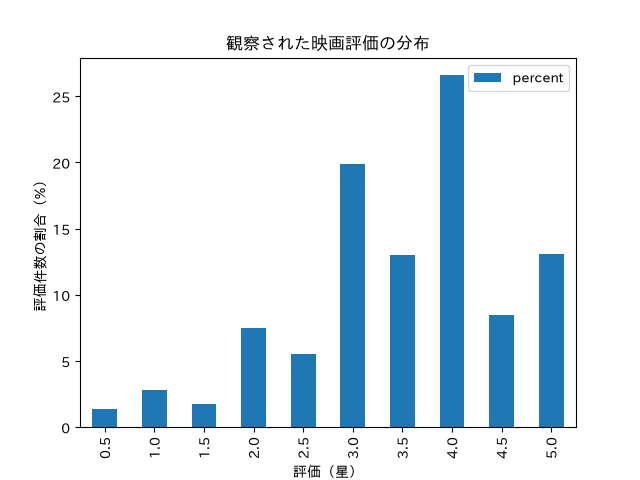

In [10]:
phase_start('chart_rating')
def show_png(png):
    display(visualization.build_image_output(png).data, raw=True)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    png = visualization.render_chart(rating_distribution,kind='bar',x='rating',y='percent',title='観察された映画評価の分布',xlabel='評価（星）',ylabel='評価件数の割合（%）')
    assert not [w for w in caught if 'Glyph' in str(w.message)], '欠落グリフを検出'
show_png(png)
phase_end('chart_rating')


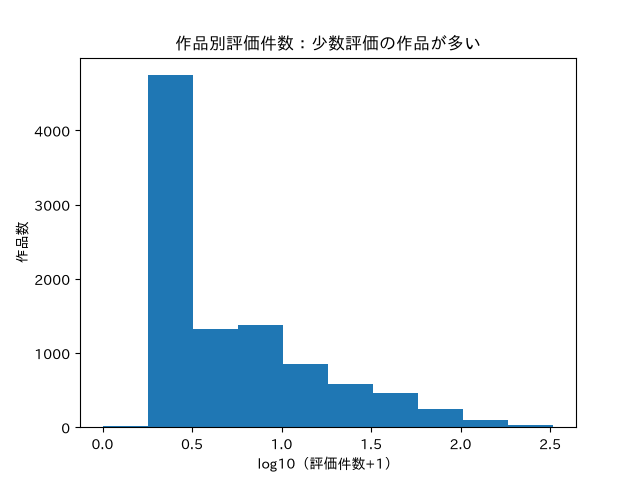

In [11]:
phase_start('chart_movie_counts')
count_plot = movie_catalog.assign(log10_n_plus1=np.log10(movie_catalog.n+1))
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    png = visualization.render_chart(count_plot,kind='hist',x='log10_n_plus1',title='作品別評価件数：少数評価の作品が多い',xlabel='log10（評価件数+1）',ylabel='作品数')
    assert not [w for w in caught if 'Glyph' in str(w.message)], '欠落グリフを検出'
show_png(png)
phase_end('chart_movie_counts')


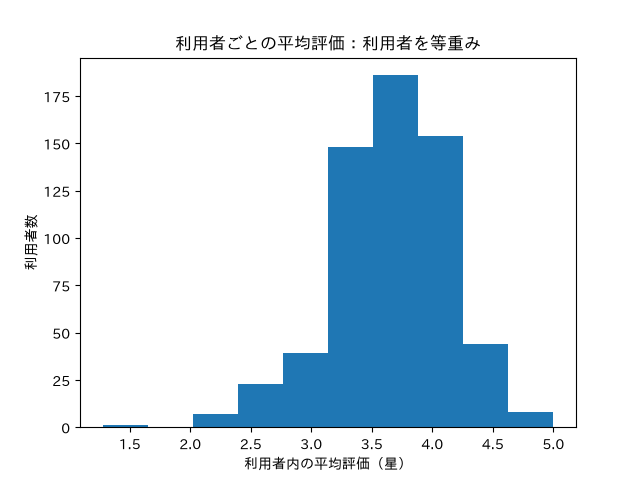

In [12]:
phase_start('chart_user_means')
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    png = visualization.render_chart(user_stats,kind='hist',x='mean',title='利用者ごとの平均評価：利用者を等重み',xlabel='利用者内の平均評価（星）',ylabel='利用者数')
    assert not [w for w in caught if 'Glyph' in str(w.message)], '欠落グリフを検出'
show_png(png)
phase_end('chart_user_means')


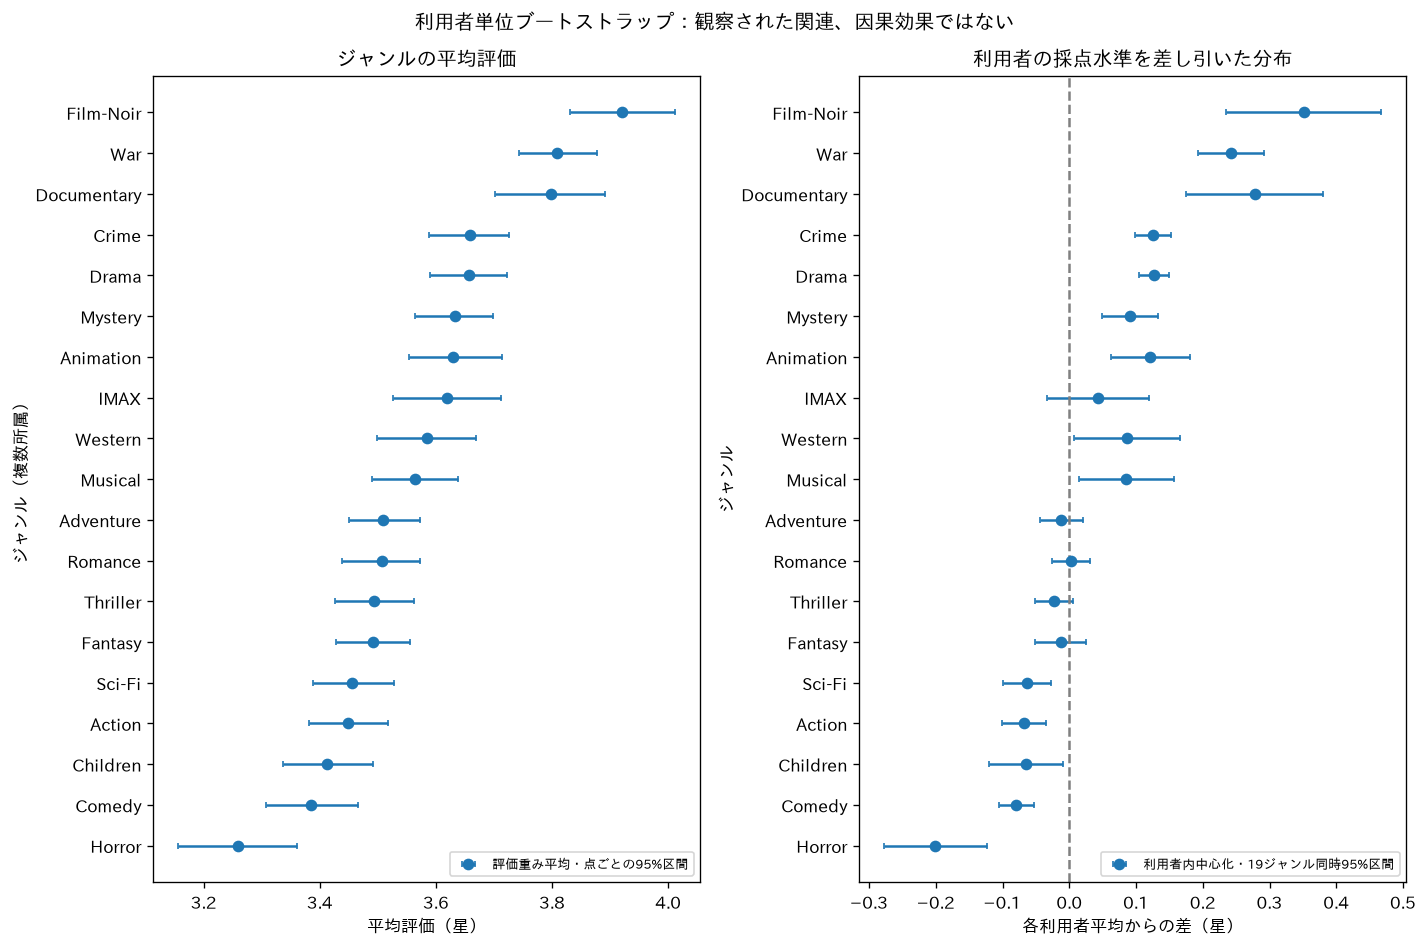

In [13]:
phase_start('chart_genre_intervals')
import matplotlib.pyplot as plt
fig,axes = plt.subplots(1,2,figsize=(12,8))
gorder = genre_stats.drop(index='(no genres listed)').sort_values('mean').index
gt = genre_stats.loc[gorder]
st = simultaneous.loc[gorder]
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    axes[0].errorbar(gt['mean'],np.arange(len(gt)),xerr=np.vstack([gt['mean']-gt.CI_low,gt.CI_high-gt['mean']]),fmt='o',capsize=2,label='評価重み平均・点ごとの95%区間')
    axes[0].set_yticks(np.arange(len(gt)),gt.index)
    axes[0].set_xlabel('平均評価（星）'); axes[0].set_ylabel('ジャンル（複数所属）')
    axes[0].set_title('ジャンルの平均評価'); axes[0].legend(loc='lower right',fontsize=8)
    axes[1].errorbar(st.centered,np.arange(len(st)),xerr=np.vstack([st.centered-st.sim_CI_low,st.sim_CI_high-st.centered]),fmt='o',capsize=2,label='利用者内中心化・19ジャンル同時95%区間')
    axes[1].axvline(0,color='gray',linestyle='--')
    axes[1].set_yticks(np.arange(len(st)),st.index)
    axes[1].set_xlabel('各利用者平均からの差（星）'); axes[1].set_ylabel('ジャンル')
    axes[1].set_title('利用者の採点水準を差し引いた分布'); axes[1].legend(loc='lower right',fontsize=8)
    fig.suptitle('利用者単位ブートストラップ：観察された関連、因果効果ではない')
    fig.tight_layout()
    buffer = io.BytesIO(); fig.savefig(buffer,format='png',bbox_inches='tight',dpi=120)
    assert not [w for w in caught if 'Glyph' in str(w.message)], '欠落グリフを検出'
plt.close(fig)
show_png(buffer.getvalue())
phase_end('chart_genre_intervals')


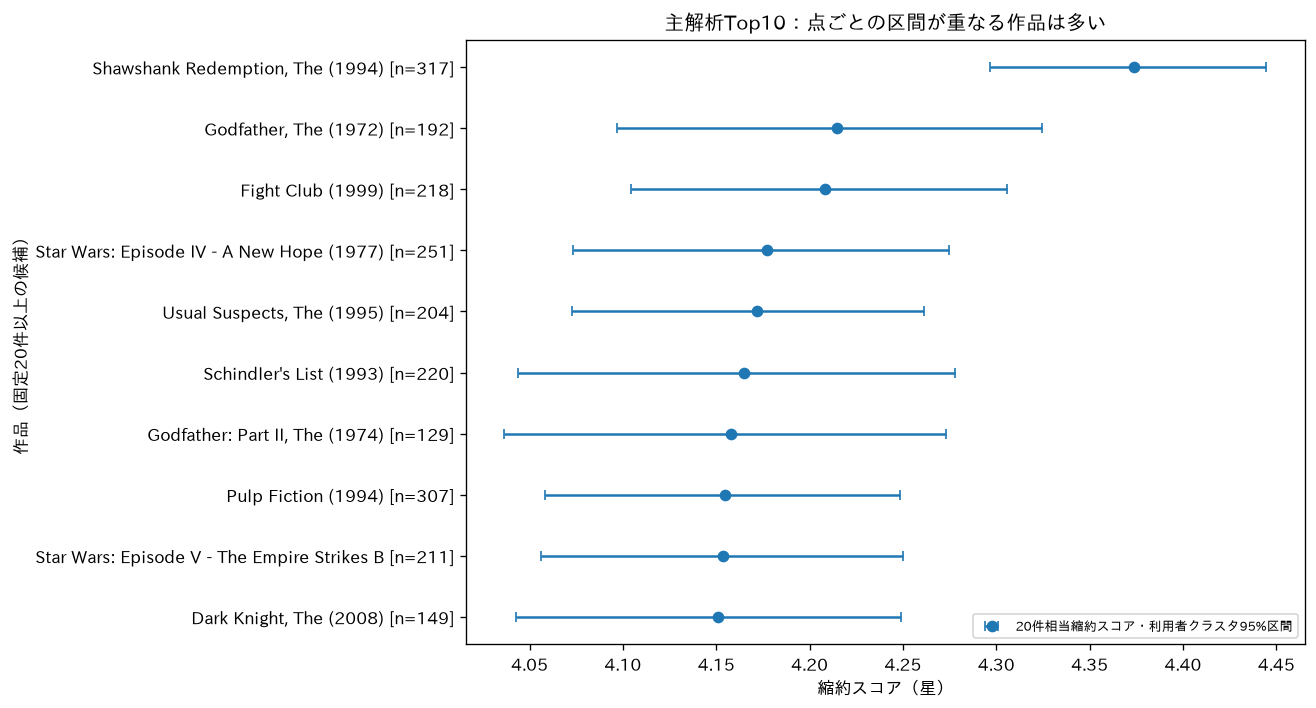

In [14]:
phase_start('chart_rank_intervals')
top = rank_table.head(10).iloc[::-1]
fig,ax = plt.subplots(figsize=(11,6))
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    ax.errorbar(top.score_m20,np.arange(len(top)),xerr=np.vstack([top.score_m20-top.score_CI_low,top.score_CI_high-top.score_m20]),fmt='o',capsize=3,label='20件相当縮約スコア・利用者クラスタ95%区間')
    labels = [f'{row.title[:43]} [n={int(row.n)}]' for _,row in top.iterrows()]
    ax.set_yticks(np.arange(len(top)),labels)
    ax.set_xlabel('縮約スコア（星）'); ax.set_ylabel('作品（固定20件以上の候補）')
    ax.set_title('主解析Top10：点ごとの区間が重なる作品は多い')
    ax.legend(loc='lower right',fontsize=8)
    fig.tight_layout()
    buffer = io.BytesIO(); fig.savefig(buffer,format='png',bbox_inches='tight',dpi=120)
    assert not [w for w in caught if 'Glyph' in str(w.message)], '欠落グリフを検出'
plt.close(fig)
show_png(buffer.getvalue())
phase_end('chart_rank_intervals')


## 使用したJupytermindモジュール

直接importし、以下を直接呼び出したものだけを記載する。pandas、NumPy、SciPy、Matplotlib、Kaggle、IPython、nbformatは外部ライブラリであり、この一覧には含めない。

| モジュール | 直接呼び出す関数・クラス・メソッド | 使用目的 |
|---|---|---|
| `ai_data_scientist.project_manager` | `ProjectHandle`, `resolve_project`, `ensure_notebook`, `ensure_data_dir`, `enqueue_write` | slug検証、指定保存先、データ保存、Notebookの直列化書込み |
| `ai_data_scientist.language_router` | `detect_language` | 日本語の検出 |
| `ai_data_scientist.lifecycle` | `register_run`, `mark_execution_start/end`, `mark_write_start/end`, `is_cancel_requested`, `get_run_status`, `mark_completed`, `wait_for_quiescence` | 実行・書込み・終了状態、協調中止、静止確認 |
| `ai_data_scientist.ingestion` | `SourceSpec`, `ingest` | 全CSV読込みと行数上限・切詰めなしの確認 |
| `ai_data_scientist.eda` | `explore` | 型・要約の確認 |
| `ai_data_scientist.data_definition` | `FieldValue`, `build_manifest`, `DataDefinitionManifest.unresolved_fields` | README定義・SHA-256・未解決定義 |
| `ai_data_scientist.analysis_assumptions` | `Assumption`, `AnalysisAssumptionManifest`, `check_manifest` | 交換可能性・尺度・欠測・因果範囲の警告 |
| `ai_data_scientist.data_quality` | `detect_anomalies` | 評価値・ID・ジャンル・欠測・一意性の意味的検査 |
| `ai_data_scientist.sensitivity` | `SensitivityPlan`, `run_sensitivity` | ランキング16仕様・ジャンル24仕様・時期4仕様の安定性 |
| `ai_data_scientist.visualization` | `render_chart`, `build_image_output` | 日本語図3点と独自誤差棒図2点のPNG出力 |
| `ai_data_scientist.insight_engine` | `extract_cited_value`, `record_insight` | 保存済み実行出力から厳密引用、根拠付き日本語結論、再現診断 |
| `ai_data_scientist.notebook_audit` | `audit_notebook` | 実行・引用根拠・`visual_audit=True`図表監査 |

### 非適用と代替の理由

独立参照データが指定・取得されていないので`dataset_validation.compare_datasets`、`data_quality.validate_anomalies`は非適用。同じratingsから作った集計を独立検証と偽らない。意味的違反・重複・欠測がないので`cleaning.clean_dataset`は不要（削除・補完0）。有界・離散評価の極値は有効値なのでz-score外れ値除去は非適用。Kaggleカタログ探索はSDKで実施し、dataset_validationの自動発見機能として扱わない。人気の逆確率重み付けは露出・視聴・非評価ログと選択確率がなく非識別。因果推論・人口代表性の補正は非適用。一般的な相関モジュールの独立観測p値は反復測定に適切でないため未使用で、Spearman相関は記述量だけを計算した。複数所属の独立群ANOVA、単発満点作品のゼロ幅ブートストラップ区間を確証として使うことも非適用。

`mcp_gateway.run_and_record`はホストのMCP client引数を必要とするが、この分析は既にネイティブJupyter MCPの`execute_cell`でNotebookセルを実行するため、カーネル内から同じカーネルを再帰実行しない。追加セルのソース・根拠・メタデータ書込みは`enqueue_write`に限定し、実際のexecution_countと出力はJupyter MCPが保存する。間接importされたgateway等を使用済みと数えない。

## Jupytermind改善候補

下記診断セルで現在の保存済み出力に対する最小再現を実施する。Kaggle認証・検索・取得は成功しており、CLI／Kaggle API／ベンチマークランナーの取得問題ではない。時期限定の少数利用者ブートストラップでのゼロ件抽出と一時的な分析セル編集のSyntaxErrorは分析コード側の問題であり、Jupytermindの不具合に分類しない。最終セルではゼロ件抽出数と参考区間を明示して解決、SyntaxErrorは修正して再実行した。

In [15]:
phase_start('module_diagnostics')
nb_saved = nbformat.read(handle.notebook_path,as_version=4)
search_cell = next(cell for cell in nb_saved.cells if cell.cell_type=='code' and "phase_start('kaggle_search')" in cell.source)
stream_text = ''.join(output.get('text','') for output in search_cell.outputs if output.output_type=='stream')
stream_cite = insight_engine.extract_cited_value({'output':stream_text},r'(確認したファイル一覧)')
improvement_candidates = []
try:
    insight_engine.record_insight(handle,'診断用：stream出力の根拠確認',search_cell.execution_count,stream_cite,'descriptive',language='ja')
except insight_engine.EvidenceMissingError as exc:
    improvement_candidates.append({'classification':'不具合候補：実行出力形式との不整合','module':'ai_data_scientist.insight_engine','function':'record_insight','reproduction':'実行済みセル2のoutput_type=stream内の文字列をextract_cited_valueで取得し、同じexecution_countでrecord_insightを呼ぶ','expected':'実行済みのstream.textに存在する引用を根拠として受理する','actual':'EvidenceMissingError。_find_evidence_cellはoutput.dataだけを探索する','impact':'通常のprint出力だけでは根拠記録が拒否される','workaround':'主結果はdisplay(Markdown(...))としてdata MIME出力を保存し引用する','related_cells':[2,24],'log':str(exc)})
else:
    write_notebook(lambda nb: nb.cells.__setitem__(slice(None),[c for c in nb.cells if not(c.cell_type=='markdown' and c.source.startswith('診断用：'))]))
semantic_probe = dd.build_manifest(source={},dataset_scope={},variables={'popularity':{'definition':dd.FieldValue('評価件数から視聴人気を推定','inferred')}})
probe_result = semantic_probe.unresolved_fields()
if not probe_result:
    improvement_candidates.append({'classification':'機能不足候補：推定定義の警告列挙','module':'ai_data_scientist.data_definition','function':'DataDefinitionManifest.unresolved_fields','reproduction':"variables.popularity.definitionをstatus='inferred'で構築しunresolved_fields()を呼ぶ",'expected':'スキル手順が要求するunknown/inferred双方を一括列挙できるAPI、または明示的な別API','actual':'0件。実装のdocstringはunknownのみと定義しているため仕様バグ断定ではなく機能不足','impact':'未検証の推定定義を手動で列挙しなければ注意が欠落する','workaround':'主manifestはREADME等で確認した項目だけverifiedとし、unknownを明示。inferredがある場合は別途走査','related_cells':[5,24],'log':{'inferred_input':asdict(semantic_probe),'unresolved_output':[]}})
improvement_candidates.append({'classification':'統合機能不足候補：ネイティブJupyter MCPとの保存競合（単体バグ断定ではない）','module':'ai_data_scientist.project_manager + ネイティブJupyter MCP','function':'enqueue_write / execute_cell保存','reproduction':'セル26実行中に対象Notebookへrecord_insightを6件追加後、MCPの実行終了保存を受ける','expected':'単一書込みプロトコルでセル追加と実行出力がともに保持される','actual':'MCPセル保存後のディスクNotebookは29セル・insight_cell_count=0、期待35セル・6件の追加Markdownが消失','impact':'実行中に同じNotebookへ加えた結論・metadataが失われる','workaround':'別staging Notebookへの記録と、実行セル保存完了後のexecute_codeによるenqueue_writeの直列コミット','related_cells':[26,'final-audit'],'log':{'observed_cell_count':29,'expected_cell_count':35,'observed_insight_cell_count':0,'recorded_insights':6,'source':'初回セル26直後のJupyter MCP execute_codeによるディスク読取り監査'}})
module_diagnostic_log = {'candidates':improvement_candidates,'count':len(improvement_candidates),'kaggle_api':'成功','runner_cli':'この診断の原因ではない','analysis_code_note':'時期限定のゼロ件抽出は統計的支持不足として明示し、通常CIを非提示'}
(data_dir/'module-diagnostics.json').write_text(json.dumps(module_diagnostic_log,ensure_ascii=False,indent=2),encoding='utf-8')
display(Markdown('改善候補診断: '+json.dumps(module_diagnostic_log,ensure_ascii=False)))
phase_end('module_diagnostics')


改善候補診断: {"candidates": [{"classification": "不具合候補：実行出力形式との不整合", "module": "ai_data_scientist.insight_engine", "function": "record_insight", "reproduction": "実行済みセル2のoutput_type=stream内の文字列をextract_cited_valueで取得し、同じexecution_countでrecord_insightを呼ぶ", "expected": "実行済みのstream.textに存在する引用を根拠として受理する", "actual": "EvidenceMissingError。_find_evidence_cellはoutput.dataだけを探索する", "impact": "通常のprint出力だけでは根拠記録が拒否される", "workaround": "主結果はdisplay(Markdown(...))としてdata MIME出力を保存し引用する", "related_cells": [2, 24], "log": "Insight '診断用：stream出力の根拠確認' に根拠となる実行済みセル(execution_count=2)が見つからないため記録を保留しました。"}, {"classification": "機能不足候補：推定定義の警告列挙", "module": "ai_data_scientist.data_definition", "function": "DataDefinitionManifest.unresolved_fields", "reproduction": "variables.popularity.definitionをstatus='inferred'で構築しunresolved_fields()を呼ぶ", "expected": "スキル手順が要求するunknown/inferred双方を一括列挙できるAPI、または明示的な別API", "actual": "0件。実装のdocstringはunknownのみと定義しているため仕様バグ断定ではなく機能不足", "impact": "未検証の推定定義を手動で列挙しなければ注意が欠落する", "workaround": "主manifestはREADME等で確認した項目だけverifiedとし、unknownを明示。inferredがある場合は別途走査", "related_cells": [5, 24], "log": {"inferred_input": {"source": {}, "dataset_scope": {}, "variables": {"popularity": {"definition": {"value": "評価件数から視聴人気を推定", "status": "inferred", "source": null}}}, "transformations": []}, "unresolved_output": []}}, {"classification": "統合機能不足候補：ネイティブJupyter MCPとの保存競合（単体バグ断定ではない）", "module": "ai_data_scientist.project_manager + ネイティブJupyter MCP", "function": "enqueue_write / execute_cell保存", "reproduction": "セル26実行中に対象Notebookへrecord_insightを6件追加後、MCPの実行終了保存を受ける", "expected": "単一書込みプロトコルでセル追加と実行出力がともに保持される", "actual": "MCPセル保存後のディスクNotebookは29セル・insight_cell_count=0、期待35セル・6件の追加Markdownが消失", "impact": "実行中に同じNotebookへ加えた結論・metadataが失われる", "workaround": "別staging Notebookへの記録と、実行セル保存完了後のexecute_codeによるenqueue_writeの直列コミット", "related_cells": [26, "final-audit"], "log": {"observed_cell_count": 29, "expected_cell_count": 35, "observed_insight_cell_count": 0, "recorded_insights": 6, "source": "初回セル26直後のJupyter MCP execute_codeによるディスク読取り監査"}}], "count": 3, "kaggle_api": "成功", "runner_cli": "この診断の原因ではない", "analysis_code_note": "時期限定のゼロ件抽出は統計的支持不足として明示し、通常CIを非提示"}

## 日本語の結論と各反復の結果・証拠・限界

以下は保存済み実行出力から引用文字列とexecution_countを取り直して作る根拠付き結論。再実行時は古い結論を置換する。各evidenceブロックの数値は上位セルの実出力と一致する。全3反復の自然言語依頼は上記履歴に原文で保持した。

In [16]:
phase_start('evidence_insights')
saved = nbformat.read(handle.notebook_path,as_version=4)
def locate_evidence(marker, pattern):
    cell = next(c for c in saved.cells if c.cell_type=='code' and marker in c.source)
    actual = '\n'.join(str(o.get('data',{}).get('text/markdown',o.get('data',{}).get('text/plain',''))) for o in cell.outputs)
    citation = insight_engine.extract_cited_value({'output':actual},pattern)
    return cell.execution_count,citation
notes = [
    ("phase_start('initial_distribution')",r'初回集計値: (\{.*\})',
     f"**作品分布・選択バイアス。** {len(ratings):,}件、{len(user_stats)}人、評価済み{len(movie_stats):,}作品。評価5件以下は{initial_summary['movies_n_le_5']:,}作品（{initial_summary['pct_rated_movies_n_le_5']:.1f}%）、1件だけが{initial_summary['movies_n1']:,}作品、未評価が18作品ある。カタログ件数上位10%の作品に評価の{100*popularity['top_10pct_movies_rating_share']:.1f}%が集まり、件数Giniは{gini:.3f}。評価単位の平均{ratings.rating.mean():.3f}、作品等重み{movie_stats['mean'].mean():.3f}、利用者等重み{user_stats['mean'].mean():.3f}は異なる推定対象であり、どれかがバイアスのない全視聴者平均という意味ではない。未観測利用者×作品の組合せは{100*popularity['unobserved_user_movie_fraction']:.1f}%で、観たが評価しなかったのか未視聴なのか不明。件数と平均のSpearman相関{popularity['spearman_n_mean']:.3f}が弱いことは選択バイアスの不存在を示さない。人気は標本の評価件数という代理量であり、露出と好みの自己選択の向き・大きさは識別できない。",'descriptive'),
    ("phase_start('cluster_bootstrap')",r'反復測定集計: (\{.*\})',
     f"**利用者による違いと反復測定。** 利用者内平均は{user_stats['mean'].min():.3f}〜{user_stats['mean'].max():.3f}、評価件数は20〜2,698。個人の採点水準と観る作品の構成が異なり、利用者内の評価を独立な100,836標本と扱わない。全評価平均の独立仮定SE={naive_se:.4f}に対して利用者クラスタSE={cluster_se:.4f}で{cluster_se/naive_se:.1f}倍、クラスタ95%区間[{repeat_summary['cluster_CI95'][0]:.3f}, {repeat_summary['cluster_CI95'][1]:.3f}]。未調整ICC={icc:.3f}は利用者間構成も含む記述量で、採点性格の純粋な分散ではない。区間は利用者相互の交換可能性と固定作品集合を仮定し、一般映画視聴者の代表性は保証しない。",'descriptive'),
    ("phase_start('cluster_bootstrap')",r'ランキング集計: (\{.*\})',
     f"**主解析ランキングの不確実性。** 観測20件以上の{len(rank_table):,}作品を対象に20件相当縮約を行うと、首位は『ショーシャンクの空に』({rank_summary['top_title']})、317件、単純平均{rank_summary['top_mean']:.3f}、縮約{rank_summary['top_score']:.3f}。固定仕様の利用者再抽出では首位頻度{100*rank_summary['top1_frequency_leader']:.1f}%、Top10頻度100%である。しかし第2位Godfatherの95%順位範囲は2〜{rank_table.iloc[1].rank_high:.1f}位、第3位Fight Clubは2〜{rank_table.iloc[2].rank_high:.1f}位と広い。順位上限23.025のような小数は百分位補間であり、実際の順位は整数。これは固定候補・固定縮約での再標本化頻度で、普遍的な首位確率や全映画の順位ではない。少数作品を除く閾値は精度と網羅性のトレードオフで、良い作品の除外を意味する可能性もある。",'descriptive'),
    ("phase_start('iteration1_rank_sensitivity')",r'反復1結果: (\{.*\})',
     f"**反復1の結果・証拠・限界。** 最低件数4水準×縮約4水準の16仕様でTop10重なりの最小は{iteration1['top10_overlap_min']:.0%}。SensitivityPlanのstable={rank_sensitivity.stable}、最大相対変化{rank_sensitivity.max_relative_deviation:.3f}（許容0.2）で、ランキング全体を頑健とは呼べない。縮約0では最低10件でSecrets & Lies、最低20件でStreetcar Named Desireが首位に変わる一方、10〜50件相当の縮約ではShawshankが首位。高評価比率のWilson下限でもShawshankが首位だがTop10重なりは{iteration1['ordinal_top10_overlap']:.0%}。1件満点作品は289あり、経験分布の0幅区間は新しい評価者の不確実性を表さない。有界尺度の保守的同時区間では5件以下全6,456作品が0.5〜5.0の全域になった。結論は『単発満点の最良認定を避ける』であって、『低件数作品の質が低い』ではない。証拠：この反復の16仕様表、低件数区間、二値高評価ランキング。限界：Hoeffdingは独立・同分布、Wilsonは点ごとの近似で選択後の同時補正がなく、いずれも露出バイアスを補正しない。",'descriptive'),
    ("phase_start('iteration2_genre_selection')",r'反復2結果: (\{.*\})',
     f"**反復2の結果・証拠・限界。** 全所属の観測平均はFilm-Noir={genre_stats.loc['Film-Noir','mean']:.3f}、War={genre_stats.loc['War','mean']:.3f}、Documentary={genre_stats.loc['Documentary','mean']:.3f}、Horror={genre_stats.loc['Horror','mean']:.3f}。中央値や低・高評価割合はジャンル表に示した。重み・多重所属・評価5件制限・高活動利用者除外を変えた24仕様でFilm-Noir−Horrorは{iteration2['gap_min']:.3f}〜{iteration2['gap_max']:.3f}、方向は全て正だがstable={genre_sensitivity_report.stable}、最大相対変化{genre_sensitivity_report.max_relative_deviation:.3f}で大きさは不安定。作品等重み(full)と分数計上(fraction)は別仕様で、fractionは各所属に1/kの寄与を配る。両ジャンルを3作品以上評価した93人の対応平均差は{pair.difference.mean():.3f}、95%区間[{pair_interval[0]:.3f}, {pair_interval[1]:.3f}]。利用者内中心化でもFilm-Noirは+0.351、Horrorは−0.201で、19ジャンル同時区間はそれぞれ[{iteration2['sim_FilmNoir_CI'][0]:.3f}, {iteration2['sim_FilmNoir_CI'][1]:.3f}]と[{iteration2['sim_Horror_CI'][0]:.3f}, {iteration2['sim_Horror_CI'][1]:.3f}]。証拠：24仕様表、対応利用者抽出、同時区間表。限界：両ジャンル評価者への条件付き結果、同一作品の重複ジャンル、選んで観る映画の違いが残るため、ジャンルを変えれば評価が上がるという因果解釈は不可。",'associational'),
    ("phase_start('iteration3_time')",r'反復3結果: (\{.*\})',
     f"**反復3の結果・証拠・限界と停止理由。** 評価日時1996〜2005年と2006〜2018年の全件平均は{time_table.loc['1996-2005','mean']:.3f}と{time_table.loc['2006-2018','mean']:.3f}で近いが、半整数評価比率は{100*time_table.loc['1996-2005','half_integer_share']:.1f}%→{100*time_table.loc['2006-2018','half_integer_share']:.1f}%に変化。Film-Noir−Horror差は全件で0.754→0.575、どちらも利用者クラスタ区間は0をまたがない。共通利用者は24人しかおらず、後期の共通ID限定Film-Noirは8人で、1,000回中1回は評価0件の抽出が生じたため通常95%区間を報告せず、有効999回に条件付けた参考区間として区別した。両期20件以上の共通332作品でも縮約首位はShawshankだが、他の上位作品は入れ替わる。stable={time_sensitivity.stable}、最大相対変化{time_sensitivity.max_relative_deviation:.3f}。証拠：時期別件数・刻み表、4仕様のジャンル差と支持不足診断、共通作品順位表。限界：同じ利用者・同じ作品の再評価パネルではなく、評価時期の因果効果を識別しない。現在2026年への外挿は不可。3回で有用な観測範囲の追加確認を終え、残る未解決点は視聴・露出・非評価ログや独立母集団データを新規取得しないと解けないため停止した。",'associational')]
stage_handle = pm.ProjectHandle(handle.name, handle.root, data_dir/'insight-staging.ipynb', data_dir)
pm.ensure_notebook(stage_handle)
lifecycle.mark_write_start(RUN_ID)
try:
    pm.enqueue_write(stage_handle, lambda nb: nb.cells.__setitem__(slice(None),[c for c in saved.cells if not c.get('metadata',{}).get('generated_insight')]))
finally:
    lifecycle.mark_write_end(RUN_ID)
for marker,pattern,text,claim in notes:
    ec,citation = locate_evidence(marker,pattern)
    lifecycle.mark_write_start(RUN_ID)
    try:
        insight_engine.record_insight(stage_handle,text,ec,citation,claim,language='ja')
    finally:
        lifecycle.mark_write_end(RUN_ID)
        phase_log.append({'phase':'insight','event':'write_complete','evidence_execution_count':ec})
def order_insights(nb):
    stage_nb = nbformat.read(stage_handle.notebook_path,as_version=4)
    generated = [c for c in stage_nb.cells if c.cell_type=='markdown' and any(c.source.startswith(text) for _,_,text,_ in notes)]
    for c in generated:
        c.metadata['generated_insight'] = True
    rest = [c for c in nb.cells if not c.get('metadata',{}).get('generated_insight')]
    cut = next((i for i,c in enumerate(rest) if c.get('id')=='final-audit-heading'),len(rest))
    nb.cells = rest[:cut]+generated+rest[cut:]
def persist_insights():
    write_notebook(order_insights)
for _,_,text,_ in notes:
    display(Markdown(text))
print('根拠付き結論6件をstagingに記録。セル保存後のJupyter MCP execute_codeでpersist_insights()を実行して対象Notebookへコミットする。')
phase_end('evidence_insights')


根拠付き結論6件をstagingに記録。セル保存後のJupyter MCP execute_codeでpersist_insights()を実行して対象Notebookへコミットする。


**作品分布・選択バイアス。** 100,836件、610人、評価済み9,724作品。評価5件以下は6,456作品（66.4%）、1件だけが3,446作品、未評価が18作品ある。カタログ件数上位10%の作品に評価の60.1%が集まり、件数Giniは0.717。評価単位の平均3.502、作品等重み3.262、利用者等重み3.657は異なる推定対象であり、どれかがバイアスのない全視聴者平均という意味ではない。未観測利用者×作品の組合せは98.3%で、観たが評価しなかったのか未視聴なのか不明。件数と平均のSpearman相関0.040が弱いことは選択バイアスの不存在を示さない。人気は標本の評価件数という代理量であり、露出と好みの自己選択の向き・大きさは識別できない。

**利用者による違いと反復測定。** 利用者内平均は1.275〜5.000、評価件数は20〜2,698。個人の採点水準と観る作品の構成が異なり、利用者内の評価を独立な100,836標本と扱わない。全評価平均の独立仮定SE=0.0033に対して利用者クラスタSE=0.0350で10.7倍、クラスタ95%区間[3.432, 3.571]。未調整ICC=0.192は利用者間構成も含む記述量で、採点性格の純粋な分散ではない。区間は利用者相互の交換可能性と固定作品集合を仮定し、一般映画視聴者の代表性は保証しない。

**主解析ランキングの不確実性。** 観測20件以上の1,297作品を対象に20件相当縮約を行うと、首位は『ショーシャンクの空に』(Shawshank Redemption, The (1994))、317件、単純平均4.429、縮約4.374。固定仕様の利用者再抽出では首位頻度99.0%、Top10頻度100%である。しかし第2位Godfatherの95%順位範囲は2〜23.0位、第3位Fight Clubは2〜25.0位と広い。順位上限23.025のような小数は百分位補間であり、実際の順位は整数。これは固定候補・固定縮約での再標本化頻度で、普遍的な首位確率や全映画の順位ではない。少数作品を除く閾値は精度と網羅性のトレードオフで、良い作品の除外を意味する可能性もある。

**反復1の結果・証拠・限界。** 最低件数4水準×縮約4水準の16仕様でTop10重なりの最小は10%。SensitivityPlanのstable=False、最大相対変化0.900（許容0.2）で、ランキング全体を頑健とは呼べない。縮約0では最低10件でSecrets & Lies、最低20件でStreetcar Named Desireが首位に変わる一方、10〜50件相当の縮約ではShawshankが首位。高評価比率のWilson下限でもShawshankが首位だがTop10重なりは50%。1件満点作品は289あり、経験分布の0幅区間は新しい評価者の不確実性を表さない。有界尺度の保守的同時区間では5件以下全6,456作品が0.5〜5.0の全域になった。結論は『単発満点の最良認定を避ける』であって、『低件数作品の質が低い』ではない。証拠：この反復の16仕様表、低件数区間、二値高評価ランキング。限界：Hoeffdingは独立・同分布、Wilsonは点ごとの近似で選択後の同時補正がなく、いずれも露出バイアスを補正しない。

**反復2の結果・証拠・限界。** 全所属の観測平均はFilm-Noir=3.920、War=3.808、Documentary=3.798、Horror=3.258。中央値や低・高評価割合はジャンル表に示した。重み・多重所属・評価5件制限・高活動利用者除外を変えた24仕様でFilm-Noir−Horrorは0.373〜0.924、方向は全て正だがstable=False、最大相対変化0.437で大きさは不安定。作品等重み(full)と分数計上(fraction)は別仕様で、fractionは各所属に1/kの寄与を配る。両ジャンルを3作品以上評価した93人の対応平均差は0.537、95%区間[0.398, 0.666]。利用者内中心化でもFilm-Noirは+0.351、Horrorは−0.201で、19ジャンル同時区間はそれぞれ[0.235, 0.468]と[-0.278, -0.124]。証拠：24仕様表、対応利用者抽出、同時区間表。限界：両ジャンル評価者への条件付き結果、同一作品の重複ジャンル、選んで観る映画の違いが残るため、ジャンルを変えれば評価が上がるという因果解釈は不可。

**反復3の結果・証拠・限界と停止理由。** 評価日時1996〜2005年と2006〜2018年の全件平均は3.506と3.499で近いが、半整数評価比率は12.8%→42.2%に変化。Film-Noir−Horror差は全件で0.754→0.575、どちらも利用者クラスタ区間は0をまたがない。共通利用者は24人しかおらず、後期の共通ID限定Film-Noirは8人で、1,000回中1回は評価0件の抽出が生じたため通常95%区間を報告せず、有効999回に条件付けた参考区間として区別した。両期20件以上の共通332作品でも縮約首位はShawshankだが、他の上位作品は入れ替わる。stable=False、最大相対変化0.237。証拠：時期別件数・刻み表、4仕様のジャンル差と支持不足診断、共通作品順位表。限界：同じ利用者・同じ作品の再評価パネルではなく、評価時期の因果効果を識別しない。現在2026年への外挿は不可。3回で有用な観測範囲の追加確認を終え、残る未解決点は視聴・露出・非評価ログや独立母集団データを新規取得しないと解けないため停止した。

**作品分布・選択バイアス。** 100,836件、610人、評価済み9,724作品。評価5件以下は6,456作品（66.4%）、1件だけが3,446作品、未評価が18作品ある。カタログ件数上位10%の作品に評価の60.1%が集まり、件数Giniは0.717。評価単位の平均3.502、作品等重み3.262、利用者等重み3.657は異なる推定対象であり、どれかがバイアスのない全視聴者平均という意味ではない。未観測利用者×作品の組合せは98.3%で、観たが評価しなかったのか未視聴なのか不明。件数と平均のSpearman相関0.040が弱いことは選択バイアスの不存在を示さない。人気は標本の評価件数という代理量であり、露出と好みの自己選択の向き・大きさは識別できない。

```evidence
{"execution_count":5,"cited_value":"{\"ratings\": 100836, \"users\": 610, \"catalog_movies\": 9742, \"rated_movies\": 9724, \"zero_rating_movies\": 18, \"movies_n_le_5\": 6456, \"pct_rated_movies_n_le_5\": 66.39243109831345, \"movies_n1\": 3446, \"five_star_mean_movies\": 296, \"rating_weighted_mean\": 3.501556983616962, \"movie_equal_mean\": 3.2624482748109633, \"user_equal_mean\": 3.6572223377474, \"user_n_min\": 20, \"user_n_max\": 2698, \"user_mean_min\": 1.275, \"user_mean_max\": 5.0, \"top_10pct_movies_rating_share\": 0.6010254274267127, \"gini_rating_counts\": 0.7168044619369669, \"unobserved_user_movie_fraction\": 0.9830317267467884, \"spearman_n_mean\": 0.03958153228619635, \"unadjusted_user_icc\": 0.19216329891739692}","claim_type":"descriptive"}
```

**利用者による違いと反復測定。** 利用者内平均は1.275〜5.000、評価件数は20〜2,698。個人の採点水準と観る作品の構成が異なり、利用者内の評価を独立な100,836標本と扱わない。全評価平均の独立仮定SE=0.0033に対して利用者クラスタSE=0.0350で10.7倍、クラスタ95%区間[3.432, 3.571]。未調整ICC=0.192は利用者間構成も含む記述量で、採点性格の純粋な分散ではない。区間は利用者相互の交換可能性と固定作品集合を仮定し、一般映画視聴者の代表性は保証しない。

```evidence
{"execution_count":6,"cited_value":"{\"global_mean\": 3.501556983616962, \"naive_iid_SE\": 0.003283072243087202, \"cluster_user_SE\": 0.03504763098099717, \"SE_ratio\": 10.675254269775222, \"cluster_CI95\": [3.4319346850432457, 3.5712847610539753], \"user_equal_CI95\": [3.6206836731226257, 3.694477770074572], \"icc_unadjusted\": 0.19216329891739692, \"bootstrap_B\": 1000, \"seed\": 44}","claim_type":"descriptive"}
```

**主解析ランキングの不確実性。** 観測20件以上の1,297作品を対象に20件相当縮約を行うと、首位は『ショーシャンクの空に』(Shawshank Redemption, The (1994))、317件、単純平均4.429、縮約4.374。固定仕様の利用者再抽出では首位頻度99.0%、Top10頻度100%である。しかし第2位Godfatherの95%順位範囲は2〜23.0位、第3位Fight Clubは2〜25.0位と広い。順位上限23.025のような小数は百分位補間であり、実際の順位は整数。これは固定候補・固定縮約での再標本化頻度で、普遍的な首位確率や全映画の順位ではない。少数作品を除く閾値は精度と網羅性のトレードオフで、良い作品の除外を意味する可能性もある。

```evidence
{"execution_count":6,"cited_value":"{\"eligible_n20\": 1297, \"top_title\": \"Shawshank Redemption, The (1994)\", \"top_score\": 4.373979642944627, \"top_mean\": 4.429022082018927, \"top_n\": 317, \"top_rank_interval\": [1.0, 1.0], \"top10_frequency_leader\": 1.0, \"top1_frequency_leader\": 0.99}","claim_type":"descriptive"}
```

**反復1の結果・証拠・限界。** 最低件数4水準×縮約4水準の16仕様でTop10重なりの最小は10%。SensitivityPlanのstable=False、最大相対変化0.900（許容0.2）で、ランキング全体を頑健とは呼べない。縮約0では最低10件でSecrets & Lies、最低20件でStreetcar Named Desireが首位に変わる一方、10〜50件相当の縮約ではShawshankが首位。高評価比率のWilson下限でもShawshankが首位だがTop10重なりは50%。1件満点作品は289あり、経験分布の0幅区間は新しい評価者の不確実性を表さない。有界尺度の保守的同時区間では5件以下全6,456作品が0.5〜5.0の全域になった。結論は『単発満点の最良認定を避ける』であって、『低件数作品の質が低い』ではない。証拠：この反復の16仕様表、低件数区間、二値高評価ランキング。限界：Hoeffdingは独立・同分布、Wilsonは点ごとの近似で選択後の同時補正がなく、いずれも露出バイアスを補正しない。

```evidence
{"execution_count":7,"cited_value":"{\"sensitivity_stable\": false, \"max_relative_deviation\": 0.9, \"top10_overlap_min\": 0.1, \"distinct_leaders\": [\"Secrets & Lies (1996)\", \"Shawshank Redemption, The (1994)\", \"Streetcar Named Desire, A (1951)\"], \"singleton_five_star_movies\": 289, \"high_rate_wilson_top_title\": \"Shawshank Redemption, The (1994)\", \"ordinal_top10_overlap\": 0.5, \"sparse_full_scale_intervals\": 6456}","claim_type":"descriptive"}
```

**反復2の結果・証拠・限界。** 全所属の観測平均はFilm-Noir=3.920、War=3.808、Documentary=3.798、Horror=3.258。中央値や低・高評価割合はジャンル表に示した。重み・多重所属・評価5件制限・高活動利用者除外を変えた24仕様でFilm-Noir−Horrorは0.373〜0.924、方向は全て正だがstable=False、最大相対変化0.437で大きさは不安定。作品等重み(full)と分数計上(fraction)は別仕様で、fractionは各所属に1/kの寄与を配る。両ジャンルを3作品以上評価した93人の対応平均差は0.537、95%区間[0.398, 0.666]。利用者内中心化でもFilm-Noirは+0.351、Horrorは−0.201で、19ジャンル同時区間はそれぞれ[0.235, 0.468]と[-0.278, -0.124]。証拠：24仕様表、対応利用者抽出、同時区間表。限界：両ジャンル評価者への条件付き結果、同一作品の重複ジャンル、選んで観る映画の違いが残るため、ジャンルを変えれば評価が上がるという因果解釈は不可。

```evidence
{"execution_count":8,"cited_value":"{\"sensitivity_stable\": false, \"max_relative_deviation\": 0.43700406188561675, \"gap_min\": 0.37265821931001186, \"gap_max\": 0.923570742844702, \"direction_all_positive\": true, \"trim_users\": 7, \"trim_rating_share\": 0.12947756753540401, \"paired_users_min3\": 93, \"paired_FilmNoir_minus_Horror\": 0.537177084464754, \"paired_CI95\": [0.3980140623814317, 0.66616391311614], \"simultaneous_genres\": 19, \"simultaneous_max_t_critical\": 2.9675333177937424, \"sim_FilmNoir_CI\": [0.23501988373857208, 0.4676469101109354], \"sim_Horror_CI\": [-0.27807759436919566, -0.12389223578327668]}","claim_type":"associational"}
```

**反復3の結果・証拠・限界と停止理由。** 評価日時1996〜2005年と2006〜2018年の全件平均は3.506と3.499で近いが、半整数評価比率は12.8%→42.2%に変化。Film-Noir−Horror差は全件で0.754→0.575、どちらも利用者クラスタ区間は0をまたがない。共通利用者は24人しかおらず、後期の共通ID限定Film-Noirは8人で、1,000回中1回は評価0件の抽出が生じたため通常95%区間を報告せず、有効999回に条件付けた参考区間として区別した。両期20件以上の共通332作品でも縮約首位はShawshankだが、他の上位作品は入れ替わる。stable=False、最大相対変化0.237。証拠：時期別件数・刻み表、4仕様のジャンル差と支持不足診断、共通作品順位表。限界：同じ利用者・同じ作品の再評価パネルではなく、評価時期の因果効果を識別しない。現在2026年への外挿は不可。3回で有用な観測範囲の追加確認を終え、残る未解決点は視聴・露出・非評価ログや独立母集団データを新規取得しないと解けないため停止した。

```evidence
{"execution_count":9,"cited_value":"{\"common_users\": 24, \"common_movies\": 3410, \"common_rank_eligible20\": 332, \"sensitivity_stable\": false, \"max_relative_deviation\": 0.23726175980863293, \"gap_direction_positive_all\": true, \"time_details\": [{\"period\": \"1996-2005\", \"scope\": \"all\", \"ratings\": 41469, \"users\": 296, \"movies\": 4867, \"FilmNoir_minus_Horror\": 0.7544633774057656, \"genre_users\": [104, 261], \"invalid_bootstrap_draws\": 0, \"CI_low\": 0.5784477194075387, \"CI_high\": 0.9025446424087193, \"conditional_valid_CI\": null, \"interval_status\": \"approximate\"}, {\"period\": \"1996-2005\", \"scope\": \"common_users_movies\", \"ratings\": 10910, \"users\": 24, \"movies\": 2981, \"FilmNoir_minus_Horror\": 0.8116381167851756, \"genre_users\": [16, 24], \"invalid_bootstrap_draws\": 0, \"CI_low\": 0.5686186183963846, \"CI_high\": 0.998809335472111, \"conditional_valid_CI\": null, \"interval_status\": \"approximate\"}, {\"period\": \"2006-2018\", \"scope\": \"all\", \"ratings\": 59367, \"users\": 338, \"movies\": 8267, \"FilmNoir_minus_Horror\": 0.5754580687713089, \"genre_users\": [142, 287], \"invalid_bootstrap_draws\": 0, \"CI_low\": 0.4273013062075572, \"CI_high\": 0.7115950120645372, \"conditional_valid_CI\": null, \"interval_status\": \"approximate\"}, {\"period\": \"2006-2018\", \"scope\": \"common_users_movies\", \"ratings\": 1599, \"users\": 21, \"movies\": 1108, \"FilmNoir_minus_Horror\": 0.8726145038167941, \"genre_users\": [8, 12], \"invalid_bootstrap_draws\": 1, \"CI_low\": null, \"CI_high\": null, \"conditional_valid_CI\": [0.5077739876760563, 1.2059219188430823], \"interval_status\": \"\u53c2\u8003\u306e\u307f\uff1a\u6709\u52b9\u62bd\u51fa\u6761\u4ef6\u4ed8\u304d\u533a\u9593\u3001\u5c11\u6570\u8a55\u4fa1\u8005\u307e\u305f\u306f\u30bc\u30ed\u4ef6\u62bd\u51fa\u3042\u308a\"}], \"time_leaders\": {\"1996-2005\": \"Shawshank Redemption, The (1994)\", \"2006-2018\": \"Shawshank Redemption, The (1994)\"}}","claim_type":"associational"}
```

## 全セル再実行・Notebook監査・ライフサイクル

最終提供前にカーネルを再起動し、全コードセルを上から順にJupyter MCPで再実行する。監査は`visual_audit=True`。最後の監査セル自身がまだ実行中ならAPIの仕様に従って除外し、保存完了後にもう一度読み取り監査を行う。ライフサイクルと監査結果はNotebook metadataおよびdata/run-report.jsonに永続化する。

### 保存プロトコルの制約と回避

ネイティブJupyter MCPは実行終了時にNotebookを保存する。この実行中に同じNotebookへenqueue_writeで追加した6つのMarkdownセルは、MCPの保存で消えた（実測セル数29、期待35）。project_managerのロックはMCP側の保存には適用されない。これはKaggle・CLI・ベンチマークランナーの問題ではなく、ネイティブJupyter MCPとの同時書込み統合の問題。対処として実行中は別のinsight-staging.ipynbへrecord_insightし、セル保存完了後にJupyter MCP execute_codeでpersist_insights()を呼んで直列コミットする。終了metadataもセル完了後にコミットする。再実行するホストも同じ順序を用いる。セル26の出力自体にも日本語結論を残すため、本文を失わない。

In [23]:
phase_start('final_audit')
report = notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
print('notebook_audit:', json.dumps(asdict(report),ensure_ascii=False,indent=2))
phase_end('final_audit')
if not report.ok:
    lifecycle.mark_failed(RUN_ID)
    raise RuntimeError('Notebook監査に未解決の指摘あり')
lifecycle.mark_completed(RUN_ID)
status = lifecycle.wait_for_quiescence(RUN_ID,timeout_s=10)
assert status.state=='completed' and status.active_cell_executions==status.pending_notebook_writes==status.locks_held==0
run_record = {'run_id':RUN_ID,'state':asdict(status),'audit_ok':report.ok,'audit':asdict(report),'phase_log':phase_log,'data_definition':definition_record,'analysis_assumptions':asdict(assumptions),'assumption_findings':[asdict(f) for f in assumption_findings],'sensitivity':{'rank':asdict(rank_sensitivity),'genre':asdict(genre_sensitivity_report),'time':asdict(time_sensitivity)},'iterations':3,'module_diagnostics':module_diagnostic_log,'chart_manual_review':'5 PNG図をMCP出力で確認：日本語・軸・凡例・誤差棒に欠けなし。長い作品名は43文字に制限。','completed_at_utc':datetime.now(timezone.utc).isoformat()}
(data_dir/'run-report.json').write_text(json.dumps(run_record,ensure_ascii=False,indent=2),encoding='utf-8')
print('終了metadataはセル保存完了後にJupyter MCP execute_codeで直列コミットする。')
print('lifecycle:',json.dumps(asdict(lifecycle.get_run_status(RUN_ID)),ensure_ascii=False))
print('全コード上から再実行: metadataのreplayと最終保存後監査に記録。')


notebook_audit: {
  "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-44-movie-ratings/notebooks/kaggle-v020-kaggle-exp-44-movie-ratings.ipynb",
  "nbformat_valid": true,
  "code_cell_count": 17,
  "executed_code_cell_count": 16,
  "unexecuted_cell_indices": [],
  "error_cell_indices": [],
  "chart_cell_indices": [
    17,
    18,
    19,
    20,
    21
  ],
  "insight_cell_count": 6,
  "findings": [
    {
      "severity": "warning",
      "message": "Trailing cell invokes audit_notebook and has not finished executing yet; excluded from unexecuted-cell findings.",
      "cell_index": 34
    }
  ],
  "visual_findings": []
}
終了metadataはセル保存完了後にJupyter MCP execute_codeで直列コミットする。
lifecycle: {"run_id": "v020-exp-44", "state": "completed", "active_cell_executions": 0, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-44-movie-ratings/notebooks/kaggle-v020-kaggle-exp-